# 3 - Exploratory Data Analysis Part 1

**Author:** M. Görkem Ulutürk

**Date:** June, 2026

## Introduction

Previously, we've imported, cleaned, and validated the data, then imputed the
missing values. Here's a quick reminder: We've

- Converted column names to lowercase
- Validated data types of columns
- Validated the data except for columns such as `fare` and `name`, where it is
not possible to do so
- Extracted a new column `title` from the passenger names, denoting the
honorifics such as Mr. and Mrs.
- Extracted a new column `deck` from the cabin numbers, such as deck "A" from
cabin "A67"
- Extracted a new column `fare_per_person` using `ticket`, `sibsp`, and
`parch` columns
- Using the `title` column, we've validated the `sex` column
- Using a random forest regressor trained on `title`, `sex`, `pclass`,
`sibsp`, and `parch`, we've imputed the missing age values
- Using a ticket-based matched and a fare-distance fallback, we've imputed the
two missing `embarked` values
- Using a recursive method, we've imputed missing `deck` values by using a
ticket-based matching and a confidence level-based random forest classifier,
where we filled missing values with high model confidence first, filled the
missing values with matched ticket numbers, and then repeated this process
until the model's confidence was dropped all the way to 0 as a last resort

In this section, our goal is to answer questions, uncover insights, and
prepare for the model-building phase. Firstly, let's recall our goal.

**Goal**: We want to understand what factors, if any, contribute to a
passenger's survival.

Questions we'll be answering throughout this notebook can be summarized as:

- What variables are correlated with `survived`?
- Are there hierarchies within features affecting survivorship? For example,
children versus middle-aged survivorship.
- Are there correlated features?

As usual, we'll start with the imports.

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.contingency_tables import Table
from statsmodels.stats.multitest import multipletests

In [2]:
df = pd.read_parquet("../data/modified/cleaned.parquet")

df.head(10)

,passengerid,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,deck,title,famsize,fare_per_person,age_was_missing
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,NaN,S,G,Mr.,2,3.62500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,C,Mrs.,2,35.64165,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,NaN,S,E,Miss.,1,7.92500,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,C,Mrs.,2,26.55000,0
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,NaN,S,E,Mr.,1,8.05000,0
5,6,0,3,"Moran, Mr. James",male,29.129369,0,0,330877,8.4583,NaN,Q,E,Mr.,1,8.45830,1
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,E46,S,E,Mr.,1,51.86250,0
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,NaN,S,G,Master.,5,4.21500,0
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,NaN,S,G,Mrs.,3,3.71110,0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,NaN,C,D,Mrs.,2,15.03540,0


Let's remind ourselves of the data structure.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   passengerid      891 non-null    int64   
 1   survived         891 non-null    int64   
 2   pclass           891 non-null    int64   
 3   name             891 non-null    str     
 4   sex              891 non-null    category
 5   age              891 non-null    float64 
 6   sibsp            891 non-null    int64   
 7   parch            891 non-null    int64   
 8   ticket           891 non-null    str     
 9   fare             891 non-null    float64 
 10  cabin            204 non-null    str     
 11  embarked         891 non-null    category
 12  deck             891 non-null    category
 13  title            891 non-null    category
 14  famsize          891 non-null    int64   
 15  fare_per_person  891 non-null    float64 
 16  age_was_missing  891 non-null    int64   
dtypes: categ

## Univariate Analysis

We'll first setup the Seaborn configuration.

In [4]:
sns.set_theme(
    style="whitegrid",
    palette="muted",
    rc={
        "axes.spines.left": True,
        "axes.spines.top": False,
        "axes.spines.right": False,
    },
)

We'll also define some helper functions.

In [5]:
def describe_col(
    data: pd.DataFrame, col: str | list[str], continuous: bool
) -> pd.DataFrame:
    """Returns descriptive statistics on the specified columns.

    Patameters
    ----------
    data : pd.DataFrame
        Input data

    col : str | list[str]
        List of columns to generate descriptive statistics for

    continuous : bool
        Whether the data is continuous or discrete. Use continuous=false for
        categorical data

    Returns
    -------
    pd.DataFrame
        Descriptive statistics table as a pandas DataFrame object
    """

    if continuous:
        return pd.DataFrame(
            data[col].agg(
                count="count",
                mean="mean",
                median="median",
                std="std",
                min="min",
                q25=lambda x: x.quantile(0.25),
                q50=lambda x: x.quantile(0.50),
                q75=lambda x: x.quantile(0.75),
                iqr=lambda x: x.quantile(0.75) - x.quantile(0.25),
                max="max",
                skew="skew",
            )
        )
    else:
        return pd.concat(
            {
                "Count": data[col].value_counts(),
                "Percentage": data[col].value_counts(normalize=True) * 100,
            },
            axis=1,
        )

### Survived

`survived` is the binary target variable.

In [6]:
describe_col(df, "survived", continuous=False)

,Count,Percentage
survived,,
0,549,61.616162
1,342,38.383838


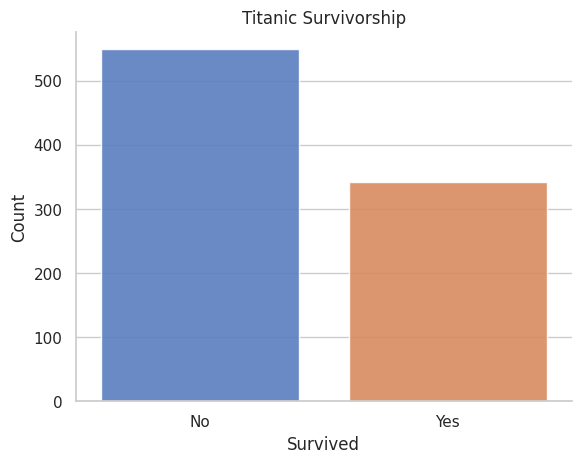

In [7]:
ax = sns.countplot(
    data=df, x="survived", hue="survived", alpha=0.9, legend=False, dodge=False
)

ax.set_xticks([0, 1], ["No", "Yes"])

ax.set_xlabel("Survived")
ax.set_ylabel("Count")
ax.set_title("Titanic Survivorship")

plt.savefig("../assets/survived_dist.png")
plt.show()

**Remarks**

- 342 passengers survived
- 549 passengers did not survive

The sinking of the Titanic resulted in approximately 1500 deaths among roughly
2200 passengers, which makes the survival rate about 31.8%. In our training
dataset, this rate is about 38.4%.

### Numeric Features

Numeric features in the dataset are as follows:

- `sibsp`: The number of siblings/spouses aboard the Titanic
- `parch`: The number of parents/children aboard the Titanic
- `fare`: Passenger fare
- `age`: Age in years

We also extracted the features:

- `famsize`: Family size is determined by `sibsp + parch + 1`
- `fare_per_person`: Fare per person is determined by passenger fare divided
by either thfaree family size or the number of times the ticket number occurs,
whichever is bigger.

#### Siblings/Siblings/Spouses

In [8]:
describe_col(df, "sibsp", continuous=True)

,sibsp
count,891.000000
mean,0.523008
median,0.000000
std,1.102743
min,0.000000
q25,0.000000
q50,0.000000
q75,1.000000
iqr,1.000000
max,8.000000


In [9]:
describe_col(df, "sibsp", continuous=False)

,Count,Percentage
sibsp,,
0,608,68.237935
1,209,23.456790
2,28,3.142536
4,18,2.020202
3,16,1.795735
8,7,0.785634
5,5,0.561167


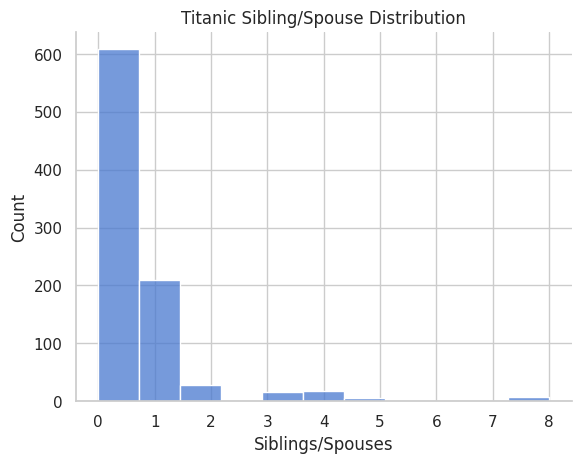

In [10]:
ax = sns.histplot(data=df, x="sibsp", bins=list(range(0, 9)), binwidth=0.75)

ax.set_xlabel("Siblings/Spouses")
ax.set_title("Titanic Sibling/Spouse Distribution")

plt.savefig("../assets/sibsp_dist.png")
plt.show()

**Remarks**

- 8 siblings is the maximum in our training data
- Mean sibling/spouse count is 0.52 with a median of 0
- A skew value of 3.7 indicates a strong positive skew
- 68.2% of the passengers have no siblings/spouses aboard
- In summary, `sibsp` is dominated by passengers with no siblings or spouses,
resulting in a highly right-skewed distribution

#### Parents/Children

In [11]:
describe_col(df, "parch", continuous=True)

,parch
count,891.000000
mean,0.381594
median,0.000000
std,0.806057
min,0.000000
q25,0.000000
q50,0.000000
q75,0.000000
iqr,0.000000
max,6.000000


In [12]:
describe_col(df, "parch", continuous=False)

,Count,Percentage
parch,,
0,678,76.094276
1,118,13.243547
2,80,8.978676
5,5,0.561167
3,5,0.561167
4,4,0.448934
6,1,0.112233


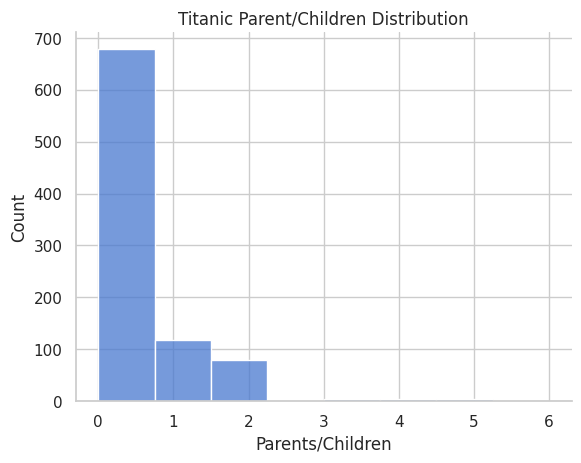

In [13]:
ax = sns.histplot(data=df, x="parch", bins=list(range(0, 7)), binwidth=0.75)

ax.set_xlabel("Parents/Children")
ax.set_title("Titanic Parent/Children Distribution")

plt.savefig("../assets/parch_dist.png")
plt.show()

**Remarks**

- 6 children are the maximum in our training data
- Mean parents/children count is 0.38 with a median of 0
- A skew value of 2.7 indicates a strong positive skew
- 76.1% of the passengers have no parents/children aboard
- In summary, `parch` is dominated by passengers with no parents/children,
resulting in a highly right-skewed distribution

**Takeaways**

We'll investigate these two features more in-depth in the multivariate data
analysis section. However, we can draw some conclusions by combining our
results.

- Since both `sibsp` and `parch` are highly right-skewed, and most passengers
had no siblings/spouses or parents/children, 68% and 76%, respectively, we can
safely conclude that most passengers traveled without close family members.
- The mean of `sibsp` being greater than `parch`, 0.52 versus 0.38, suggests
that siblings were traveling without their parents or couples without any
children. The latter is more plausible in this context.

Note that we do not declare a passenger with `sibsp == 0 & parch == 0` as
someone who traveled solo. It simply means they did not travel with close
family members. In fact, it was quite common among first-class passengers to
travel with maids or assistants.

#### Age & Age Groups

Although `age_group` is technically a categorical feature, we'll analyze it in
this section together with the `age` column.

Before we start our analysis, let's define the age groups we'll use. We will
stick to these definitions throughout the project.

Age Interval | Class
-------------|------
0-12 Years   | Child
13-18 Years  | Youth
19-24 Years  | Young Adult
25-44 Years  | Adult
45-64 Years  | Middle Aged
65+          | Aged

**NOTE:** We did not have any cultural, socioeconomic, or other considerations
to make this classification. It's purely for interpretation purposes. If such
a grouping is needed for statistical inference or model building, we'll make
the distinctions in a more concrete way. For our purposes, these should serve
as a decent guideline. Additionally, the fact that we're set to develop a
tree-based model means that making such virtual distinctions could affect
model performance in a negative way.

**NOTE 2:** In the previous versions of this notebook, we defined an "infant"
age group for ages between 0 and 1, and a child was defined as an age group
between 1 and 12. This approach created data assumption violations for
chi-square tests later in the bivariate analysis section. Since we run
statistical tests on the `age_group` column prior to bivariate analysis,
changing the data structure after one test and running other tests would
disregard the results of the first tests. Therefore, we dropped the infant
group altogether to have a consistent testing methodology and test results.

Recall that we've imputed missing values in this column. We'll first analyze
the raw age data.

In [14]:
describe_col(df.loc[df["age_was_missing"] == 0], "age", continuous=True)

,age
count,714.000000
mean,29.699118
median,28.000000
std,14.526497
min,0.420000
q25,20.125000
q50,28.000000
q75,38.000000
iqr,17.875000
max,80.000000


**Remarks**

 - The youngest passenger is 0.42 years old, while the oldest passenger is 80.
     - Recall from the data dictionary that if a passenger's `age < 1`, then
     the age is expressed as a fraction. In this case, the said passenger is
     roughly 22 weeks old.
 - Median age of 28 is very close to the mean age of 29.7.
 - A standard deviation of 14.5 indicates that the age feature is quite spread
 out.
 - About half the passengers are young adults and adults.
     - We'll analyze the age groups separately.

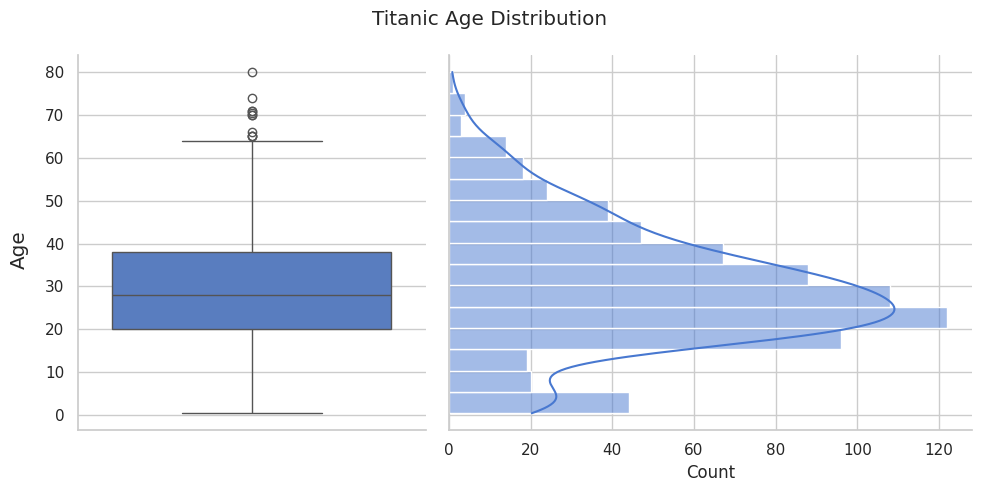

In [15]:
fig, axes = plt.subplots(
    nrows=1, ncols=2, sharey=True, gridspec_kw={"width_ratios": [0.4, 0.6]}
)
fig.set_figheight(5)
fig.set_figwidth(10)

sns.boxplot(data=df.loc[df["age_was_missing"] == 0], y="age", ax=axes[0])
sns.histplot(
    data=df.loc[df["age_was_missing"] == 0],
    y="age",
    binwidth=5,
    kde=True,
    ax=axes[1],
)

axes[0].set(ylabel=None)
fig.supylabel("Age")
fig.suptitle("Titanic Age Distribution")

plt.tight_layout()
plt.savefig("../assets/age_dist.png")
plt.show()

**Remarks**

- Data is approximately symmetric about the median with a slight positive
skew.
- Data is unimodal.
- There are several high-age outliers above age ~65.
    - These statistical outliers are most likely genuine data rather than
    errors based on historical facts.
- There are no outliers on the lower end; the left tail is less extreme
relative to the IQR.
- IQR is roughly between 20 and 40 years, which falls into the young adult &
adult age groups.

Let's also compare imputed age values with raw age data.

In [16]:
pd.concat(
    {
        "raw": describe_col(
            df.loc[df["age_was_missing"] == 0], "age", continuous=True
        ),
        "modified": describe_col(df, "age", continuous=True),
    },
    axis=1,
)

,raw,modified
,age,age
count,714.000000,891.000000
mean,29.699118,29.529713
median,28.000000,29.129369
std,14.526497,13.651124
min,0.420000,0.420000
q25,20.125000,21.000000
q50,28.000000,29.129369
q75,38.000000,36.000000
iqr,17.875000,15.000000


Recall that we've imputed the age feature by using a random forest regressor
model trained on `title`, `sex`, `pclass`, `sibsp`, and `parch`. By looking at
the table, we can understand the following:

- Entry count increased from 714 to 891
- Mean age decreased by about 0.57%, while the median age decreased by about
4.03%
- Standard deviation also decreased
- The minimum and maximum ages remained the same
- Skewness increased by 3.51%

One important note here is that none of these changes are extreme. For one
thing, imputed values did not drastically change any descriptive statistic.
Given we've imputed about 20% of the whole data, the noise introduced seems
minimal from what we can tell. Let's also compare the distributions.

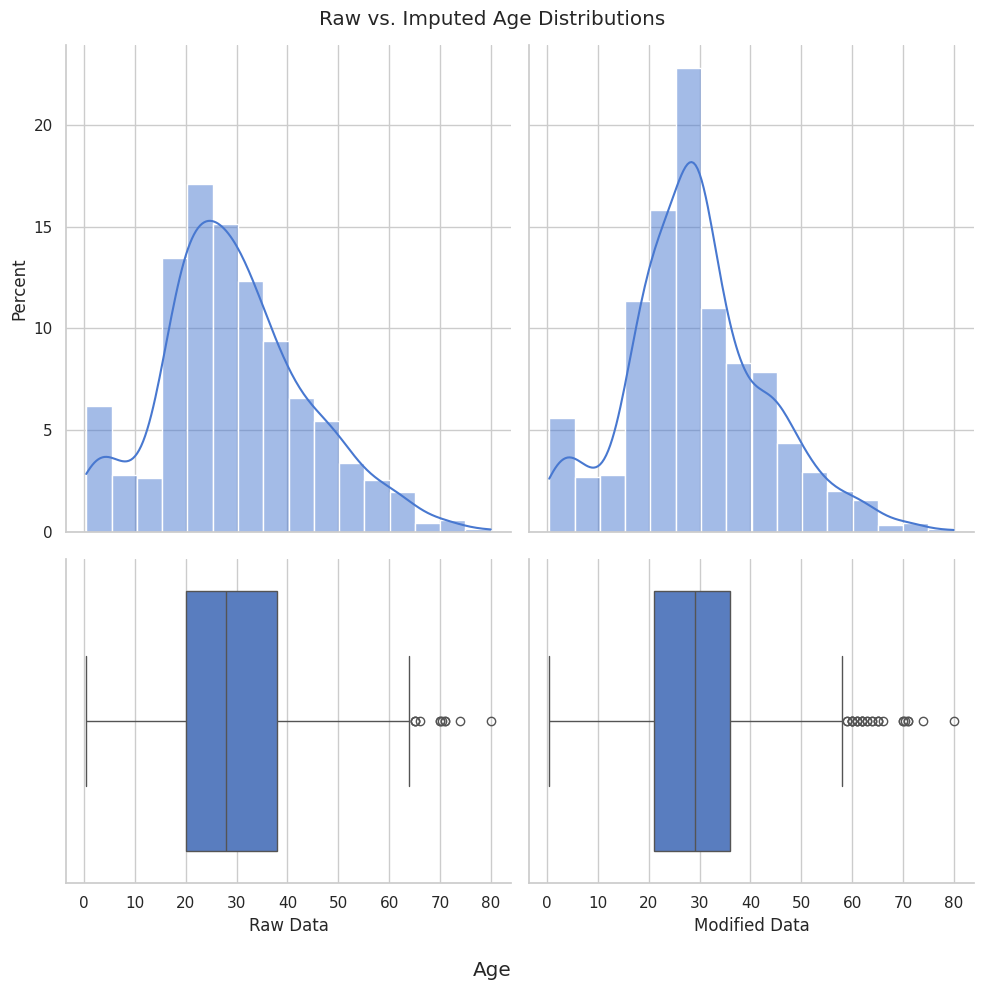

In [17]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    sharex="col",
    sharey="row",
    gridspec_kw={"height_ratios": [0.6, 0.4]},
)
fig.set_figheight(10)
fig.set_figwidth(10)

axes[1, 0].set(xlabel="Raw Data")
axes[1, 1].set(xlabel="Modified Data")
fig.supxlabel("Age")
fig.suptitle("Raw vs. Imputed Age Distributions")

sns.histplot(
    data=df.loc[df["age_was_missing"] == 0],
    x="age",
    binwidth=5,
    kde=True,
    ax=axes[0, 0],
    stat="percent",
)
sns.histplot(
    data=df, x="age", binwidth=5, kde=True, ax=axes[0, 1], stat="percent"
)
sns.boxplot(data=df.loc[df["age_was_missing"] == 0], x="age", ax=axes[1, 0])
sns.boxplot(data=df, x="age", ax=axes[1, 1])

plt.tight_layout()
plt.savefig("../assets/raw_vs_imputed_age_comparison.png")
plt.show()

Distributions look similar except around the median. Neighborhood around the
median has a steeper curve. Tails are similar but smoother. Now, let's also
plot the age groups we defined earlier.

In [18]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 12, 18, 24, 44, 64, 100],
    labels=[
        "Child",
        "Youth",
        "Young Adult",
        "Adult",
        "Middle Aged",
        "Aged",
    ],
    right=False,
    include_lowest=True,
)

In [19]:
describe_col(df.loc[df["age_was_missing"] == 0], "age_group", continuous=False)

,Count,Percentage
age_group,,
Adult,343,48.039216
Young Adult,134,18.767507
Middle Aged,111,15.546218
Child,68,9.523810
Youth,45,6.302521
Aged,13,1.820728


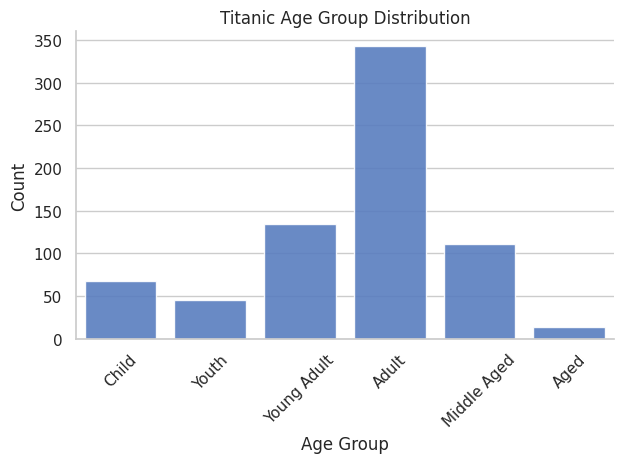

In [20]:
ax = sns.countplot(
    data=df.loc[df["age_was_missing"] == 0],
    x="age_group",
    alpha=0.9,
    legend=False,
)

plt.xticks(rotation=45)

ax.set_xlabel("Age Group")
ax.set_ylabel("Count")
ax.set_title("Titanic Age Group Distribution")

plt.tight_layout()
plt.savefig("../assets/age_group_dist.png")
plt.show()

**Remarks**

- Adults are the majority group with over 48% of the passengers
- Less than 16% of the passengers are younger than 18
- Only about 1.82% of the passengers were 65 or older

#### Fare & Fare per Person

In [21]:
print(df.fare.mean())
df.sort_values(by="fare", ascending=False)["fare"].head(21)

32.204207968574636


679    512.3292
258    512.3292
737    512.3292
88     263.0000
438    263.0000
341    263.0000
27     263.0000
742    262.3750
311    262.3750
299    247.5208
118    247.5208
700    227.5250
716    227.5250
380    227.5250
557    227.5250
527    221.7792
377    211.5000
779    211.3375
730    211.3375
689    211.3375
318    164.8667
Name: fare, dtype: float64

`fare` column's mean is 32.2, while the maximum value is 512.3292. Therefore,
plotting without filtering makes the visual not easily readable. Hence, we'll
filter the maximum values for the graph.

In [22]:
fare_desc = describe_col(df, "fare", continuous=True)
print(fare_desc)

              fare
count   891.000000
mean     32.204208
median   14.454200
std      49.693429
min       0.000000
q25       7.910400
q50      14.454200
q75      31.000000
iqr      23.089600
max     512.329200
skew      4.787317


**Remarks**

- The minimum fare is GBP 0, while the highest fare is GBP 512.
   - The highest fare is historically accurate in this case.
- Median fare is GBP 14.5 while the mean is 32.2.
- The standard deviation is GBP 49.7, which is quite high, especially compared
to the mean. Thus, the data is quite spread out.
- About half the passengers paid GBP 14.5 or less, 25% of whom paid about GBP
7.9 or less.
- About 25% of the passengers paid more than GBP 31.

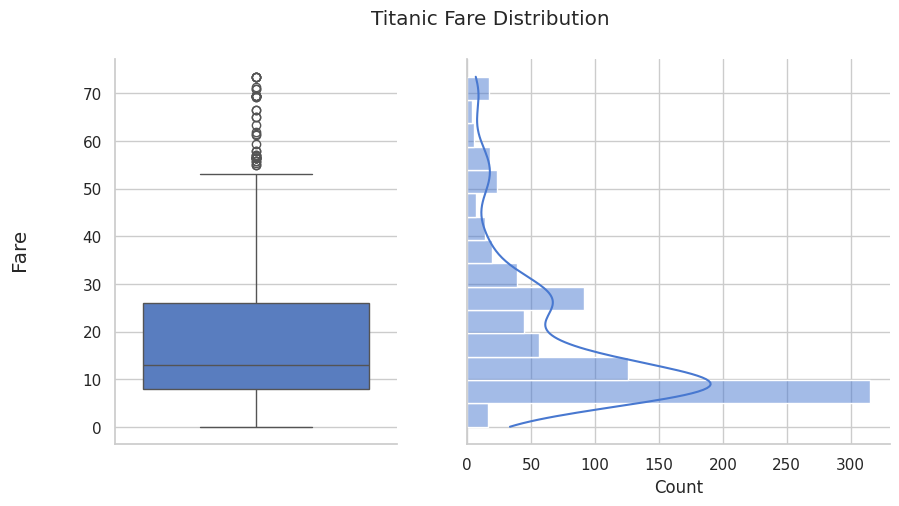

In [23]:
fig, axes = plt.subplots(
    nrows=1, ncols=2, sharey=True, gridspec_kw={"width_ratios": [0.4, 0.6]}
)
fig.set_figheight(5)
fig.set_figwidth(10)

sns.boxplot(data=df.loc[df["fare"] <= 75], y="fare", ax=axes[0])
sns.histplot(
    data=df.loc[df["fare"] <= 75],
    y="fare",
    binwidth=5,
    kde=True,
    ax=axes[1],
)

axes[0].set(ylabel=None)
fig.supylabel("Fare")
fig.suptitle("Titanic Fare Distribution")

plt.savefig("../assets/fare_dist.png")
plt.show()

**Remarks**

- Data is extremely skewed. A skew value of 4.79 indicates an extreme positive
skew.
- There are a lot of statistical outliers above ~GBP 60.
   - In fact, there are 20 outliers detected by the z-test, or 116 outliers
   detected using IQR.
   - However, note that these statistical outliers are highly likely to be
   legitimate values. In reality, the Titanic had luxurious suites with very
   high markups. For example, the highest value, GBP 512, is historically
   accurate.
- There are no outliers on the lower end; the left tail is less extreme
relative to the IQR.
- IQR is about GBP 23.1
- The distribution appears to be trimodal, possibly median fares per passenger
class. We'll check this claim later in the bivariate analysis section.

Below are the IQR and z-score tests for outliers.

In [24]:
iqr = fare_desc.loc["iqr", "fare"]
q3 = fare_desc.loc["q75", "fare"]

if isinstance(iqr, np.float64) and isinstance(q3, np.float64):
    upper_lim = q3 + 1.5 * iqr
    print(f"Outlier count using IQR: {df[df.fare > upper_lim].shape[0]}")
    z_scores = np.asarray(stats.zscore(df["fare"]))
    print(f"Outlier count using z-scores: {np.count_nonzero(z_scores > 3)}")

Outlier count using IQR: 116
Outlier count using z-scores: 20


Let's also plot log-scaled `fare`.

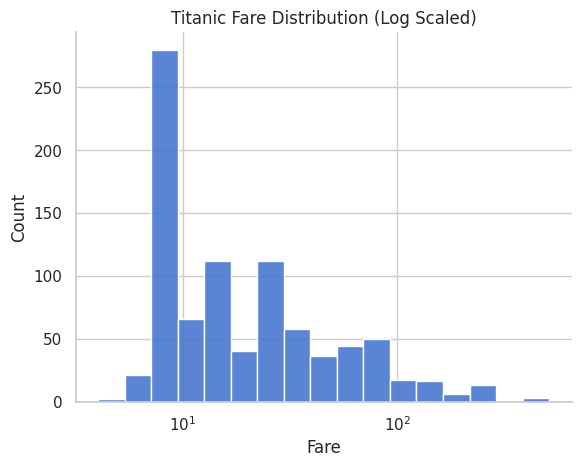

In [25]:
ax = sns.histplot(data=df, x="fare", alpha=0.9, legend=False, log_scale=True)

ax.set_xlabel("Fare")
ax.set_ylabel("Count")
ax.set_title("Titanic Fare Distribution (Log Scaled)")

plt.savefig("../assets/fare_logscaled_dist.png")
plt.show()

We should also analyze the `fare_per_person` feature. Recall that this column
was extracted by dividing a passenger's fare by group size, which was
determined as the maximum of either family size or the number of occurrences
of that passenger's ticket number.

In [26]:
describe_col(df, "fare_per_person", continuous=True)

,fare_per_person
count,891.000000
mean,15.463672
median,8.050000
std,18.187769
min,0.000000
q25,7.239600
q50,8.050000
q75,14.775000
iqr,7.535400
max,221.779200


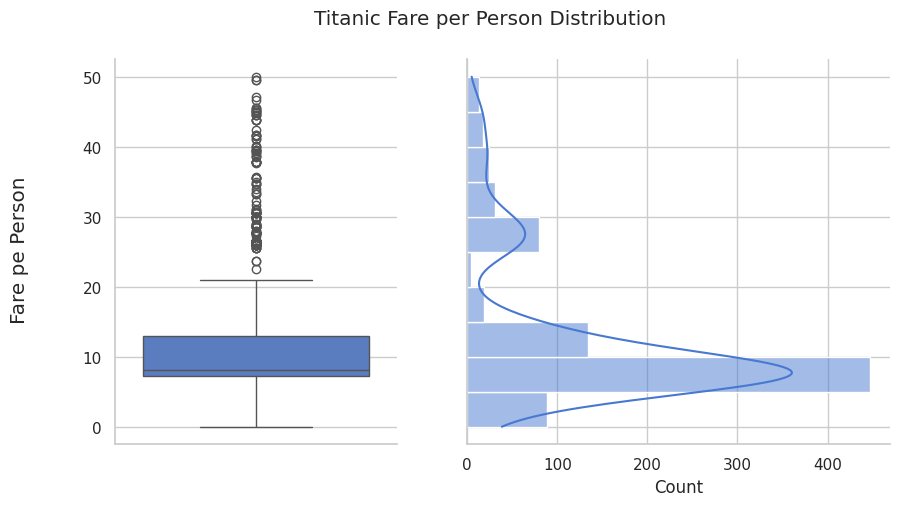

In [27]:
fig, axes = plt.subplots(
    nrows=1, ncols=2, sharey=True, gridspec_kw={"width_ratios": [0.4, 0.6]}
)
fig.set_figheight(5)
fig.set_figwidth(10)

sns.boxplot(
    data=df.loc[df["fare_per_person"] <= 50], y="fare_per_person", ax=axes[0]
)
sns.histplot(
    data=df.loc[df["fare_per_person"] <= 50],
    y="fare_per_person",
    binwidth=5,
    kde=True,
    ax=axes[1],
)

axes[0].set(ylabel=None)
fig.supylabel("Fare pe Person")
fig.suptitle("Titanic Fare per Person Distribution")

plt.savefig("../assets/fare_per_person_dist.png")
plt.show()

**Remarks**

- Mean fare per person is GBP 15.5
- Median fare per person is GBP 8.05, which makes sense historically
- Similar to fare, data contains a lot of outliers ranging all the way to GBP
221.8
- Although the original `fare` feature was trimodal, we only see two peaks in
the `fare_per_person` distribution
  - We probably lost some information due to approximation

#### Family Size

In [28]:
describe_col(df, "famsize", continuous=True)

,famsize
count,891.000000
mean,1.904602
median,1.000000
std,1.613459
min,1.000000
q25,1.000000
q50,1.000000
q75,2.000000
iqr,1.000000
max,11.000000


In [29]:
describe_col(df, "famsize", continuous=False)

,Count,Percentage
famsize,,
1,537,60.269360
2,161,18.069585
3,102,11.447811
4,29,3.254770
6,22,2.469136
5,15,1.683502
7,12,1.346801
11,7,0.785634
8,6,0.673401


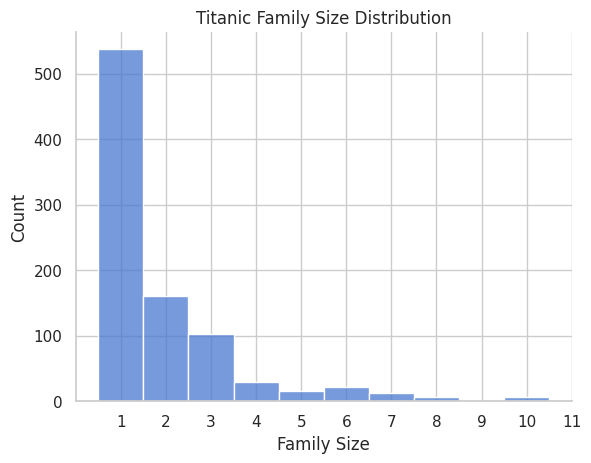

In [30]:
ax = sns.histplot(data=df, x="famsize", bins=list(range(1, 12)), binwidth=1)

ax.set_xticks([x + 0.5 for x in range(1, 12)], [str(x) for x in range(1, 12)])
ax.set_xlabel("Family Size")
ax.set_title("Titanic Family Size Distribution")

plt.savefig("../assets/famsize_dist.png")
plt.show()

**Remarks**

- The vast majority of the passengers were solo travelers, with 60.3% of the
population
- Mean family size is 1.90
- The most populated family consists of 11 members
- The distribution appears similar to a reciprocal curve

### Categorical Features

Categorical features in the dataset are as follows:

- `pclass`: Passenger class (1-3, based on tickets and fares)
- `name`: Passenger name
- `sex`: Passenger sex
- `ticket`: Ticket number, same across members of a group (such as a family)
- `cabin`: Room occupied by a passenger, sort of a door number in a hotel
- `embarked`: Port of embarkation

We've also extracted features:

- `deck`: Deck that the passenger's cabin belongs to
- `title`: Honorific title extracted from a passenger's name
- `age_group`: Ages binned into groups, such as children, adults, etc.

We will not analyze the `name`, `ticket`, and `cabin` columns. Names are not
going to be analyzed because the feature can be reliably used only for feature
extraction or data validation, and we handled both cases previously. The same
case applies to the ticket as well. The cabin column contained lots of missing
data, and by itself, it is hard to interpret. Therefore, we'll analyze the
feature-extracted `deck` column instead.

#### Passenger Class

In [31]:
describe_col(df, "pclass", continuous=False)

,Count,Percentage
pclass,,
3,491,55.106622
1,216,24.242424
2,184,20.650954


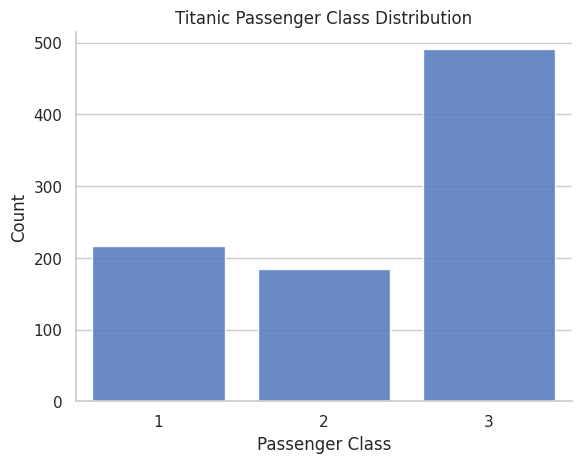

In [32]:
ax = sns.countplot(data=df, x="pclass", alpha=0.9, legend=False)

ax.set_xlabel("Passenger Class")
ax.set_ylabel("Count")
ax.set_title("Titanic Passenger Class Distribution")

plt.savefig("../assets/pclass_dist.png")
plt.show()

**Remarks**

- More than half of the passengers were third-class
- There are more first-class passengers than second-class

#### Sex

In [33]:
describe_col(df, "sex", continuous=False)

,Count,Percentage
sex,,
male,577,64.758698
female,314,35.241302


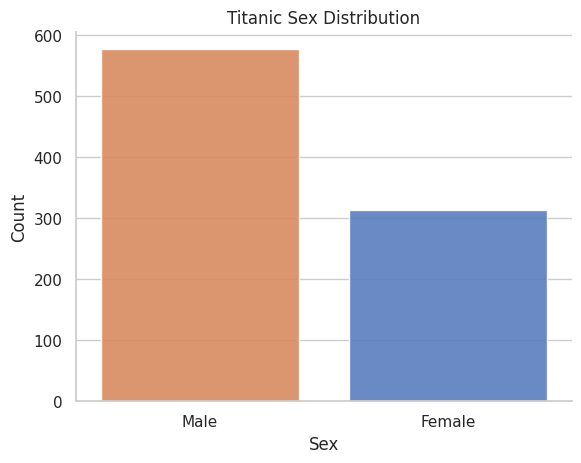

In [34]:
ax = sns.countplot(
    data=df,
    x="sex",
    hue="sex",
    alpha=0.9,
    legend=False,
    dodge=False,
    order=["male", "female"],
)

ax.set_xticks([0, 1], ["Male", "Female"])

ax.set_xlabel("Sex")
ax.set_ylabel("Count")
ax.set_title("Titanic Sex Distribution")

plt.savefig("../assets/sex_dist.png")
plt.show()

**Remarks**

- Out of 891 passengers, 577 are male, 64.8% of the passengers, while 314 are
female

#### Embarked

In [35]:
describe_col(df, "embarked", continuous=False)

,Count,Percentage
embarked,,
S,644,72.278339
C,170,19.079686
Q,77,8.641975


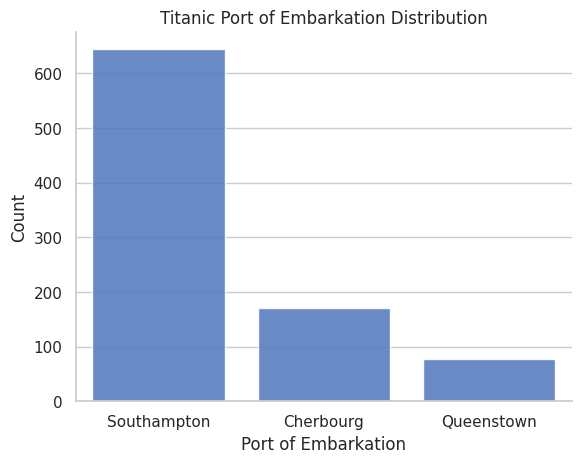

In [36]:
ax = sns.countplot(
    data=df, x="embarked", alpha=0.9, legend=False, order=["S", "C", "Q"]
)

plt.xticks([0, 1, 2], ["Southampton", "Cherbourg", "Queenstown"])

ax.set_xlabel("Port of Embarkation")
ax.set_ylabel("Count")
ax.set_title("Titanic Port of Embarkation Distribution")

plt.savefig("../assets/embarked_dist.png")
plt.show()

**Remarks**

- 72.3% of the passengers embarked from Southampton, England
- 19.1% of the passengers embarked from Cherbourg, France
- 8.64% of the passengers embarked from Queenstown, Ireland

#### Deck

Recall that we've extracted the deck feature from the `cabin` column, then
imputed the missing values. About 77% of the `deck` data was missing prior to
imputation.

In [37]:
describe_col(df, "deck", continuous=False)

,Count,Percentage
deck,,
F,268,30.078563
E,250,28.058361
D,120,13.468013
G,100,11.223345
C,79,8.866442
B,56,6.285073
A,17,1.907969
T,1,0.112233


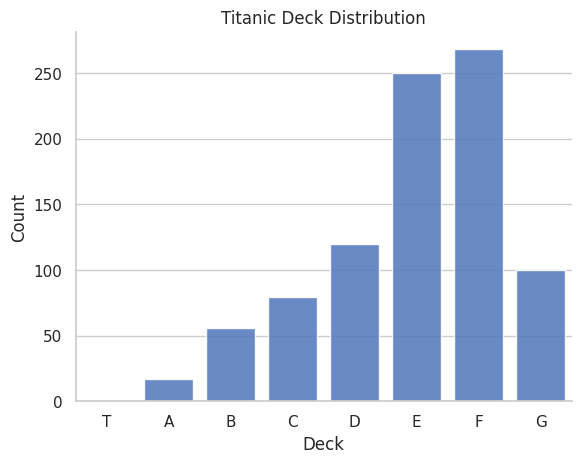

In [38]:
ax = sns.countplot(
    data=df,
    x="deck",
    alpha=0.9,
    legend=False,
    order=["T", "A", "B", "C", "D", "E", "F", "G"],
)

ax.set_xlabel("Deck")
ax.set_ylabel("Count")
ax.set_title("Titanic Deck Distribution")

plt.savefig("../assets/deck_dist.png")
plt.show()

**Remarks**

- The majority of the passengers occupied E & F decks
- Deck T had only 1 passenger
  - Recall that we've validated the data already; there's no mistake here
- Data is negatively skewed
- Mode of deck is deck F

#### Title

Recall that we've extracted the title feature from the `name` column.

In [39]:
describe_col(df, "title", continuous=False)

,Count,Percentage
title,,
Mr.,517,58.024691
Miss.,182,20.426487
Mrs.,125,14.029181
Master.,40,4.489338
Dr.,7,0.785634
Rev.,6,0.673401
Col.,2,0.224467
Major.,2,0.224467
Mlle.,2,0.224467


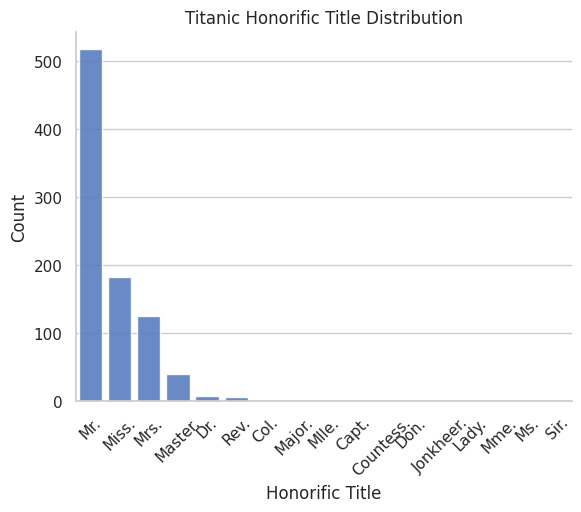

In [40]:
ax = sns.countplot(
    data=df,
    x="title",
    alpha=0.9,
    legend=False,
    order=df["title"].value_counts().sort_values(ascending=False).index,
)

plt.xticks(rotation=45)

ax.set_xlabel("Honorific Title")
ax.set_ylabel("Count")
ax.set_title("Titanic Honorific Title Distribution")

plt.show()

This plot isn't exactly easy to read. Let's group titles with 1 or 2
occurrences into a combined group called *"Others"* and plot again.

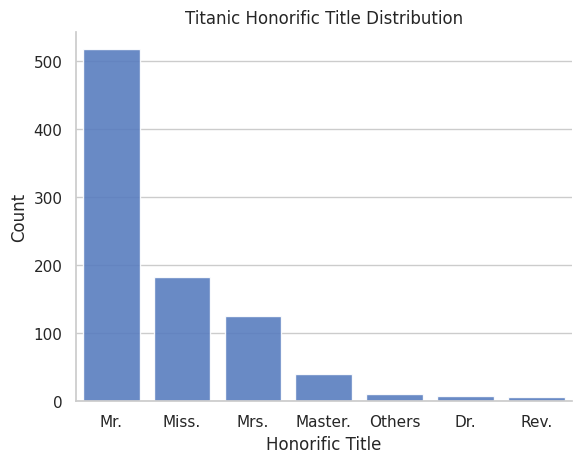

In [41]:
titles_df = df["title"].value_counts().reset_index()
titles_df.columns = ["title", "count"]
titles_df.loc[-1] = ["Others", sum(titles_df["count"] <= 2)]
titles_df = (
    titles_df.drop(titles_df[titles_df["count"] <= 2].index)
    .sort_values(by="count", ascending=False)
    .reset_index(drop=True)
)

ax = sns.barplot(
    data=titles_df,
    x="title",
    y="count",
    alpha=0.9,
    legend=False,
)

ax.set_xlabel("Honorific Title")
ax.set_ylabel("Count")
ax.set_title("Titanic Honorific Title Distribution")

plt.savefig("../assets/title_dist.png")
plt.show()

**Remarks**

- More than half the passengers, 58% to be precise, were Mr.
- Occupation-related titles, such as Dr. or Col., are rare
- The majority of the passengers had English honorifics, but there were also
some honorifics in French, Italian, etc.

## Bivariate Analysis

We'll investigate data relations between our target variable and features.

We'll start by defining some helper functions.

In [42]:
P_VALS = {}


def describe_surv_vs_col(
    data: pd.DataFrame, col: str, continuous: bool
) -> pd.DataFrame:
    """Generate a descriptive statistics table between survived and a variable.

    Parameters
    ----------
    data : pd.DataFrame
        Input data

    col : str
        Column corresponding to the variable

    continuous : bool
        Whether the variable to be compared is continuous or not

    Returns
    -------

    pd.DataFrame
        Resulting descriptive statistics table
    """
    if continuous:
        result = data.groupby("survived").agg(
            count=(col, "count"),
            mean=(col, "mean"),
            median=(col, "median"),
            std=(col, "std"),
            min=(col, "min"),
            max=(col, "max"),
            q25=(col, lambda x: x.quantile(0.25)),
            q75=(col, lambda x: x.quantile(0.75)),
        )
        if isinstance(result, pd.DataFrame):
            return result
        else:
            raise ValueError(
                "Aggregated object is not a pd.DataFrame instance."
            )
    else:
        _counts = data.groupby(by=col)["survived"].value_counts().unstack()
        _percents = (
            (
                data.groupby(by=col)["survived"]
                .value_counts(normalize=True)
                .unstack()
                * 100
            )
            .round(1)
            .astype("str")
        )

        return pd.concat({"Count": _counts, "Percentage": _percents}, axis=1)


def chi_square_test(
    data: pd.DataFrame,
    feature: str,
    target: str = "survived",
    alpha: float = 0.05,
    heatmap: bool = True,
    xlabel: str = "",
    ylabel: str = "",
    title: str = "",
    name: str | None = None,
) -> tuple | None:
    """Conducts a chi-square test of independence and returns the contingency
    table and the test result."""
    contingency_table = pd.crosstab(data[feature], data[target])
    _chi2, _pval, _dof, _expected = stats.chi2_contingency(contingency_table)

    if not (
        isinstance(_chi2, (float, np.floating))
        and isinstance(_pval, (float, np.floating))
        and isinstance(_dof, (int, np.integer))
        and isinstance(_expected, np.ndarray)
    ):
        raise TypeError(
            "stats._chi2_contingency returned un_expected types: "
            f"{type(_chi2)}, {type(_pval)}, {type(_dof)}, {type(_expected)}"
        )

    cells = _expected.size
    lt5 = (_expected < 5).sum()
    lt1 = (_expected < 1).sum()

    if lt1 > 0:
        print("Chi-square assumptions violated: _expected counts < 1 detected.")
        print("Contingency Table:")
        print(contingency_table)
        return None

    if lt5 / cells > 0.20:
        print(
            "Chi-square assumptions violated: "
            f"{lt5}/{cells} _expected counts < 5 (>20%)."
        )
        print("Contingency Table:")
        print(contingency_table)
        return None

    if _pval < alpha:
        print(f"p-value < {alpha}: reject the null hypothesis")
    else:
        print(f"p-value >= {alpha}: fail to reject the null hypothesis")

    if heatmap:
        table = Table(contingency_table)
        table.test_nominal_association()

        std_resids = table.standardized_resids

        _ax = sns.heatmap(
            std_resids,
            annot=True,
            cmap="flare",
            center=0,
            fmt=".2f",
        )

        _ax.set_xlabel(xlabel)
        _ax.set_ylabel(ylabel)
        _ax.set_title(title)

        if name:
            plt.savefig(f"../assets/{name}.png")

        plt.show()

    if feature in P_VALS:
        feature = feature + "_rerun"

    P_VALS[feature] = _pval

    return _chi2, _pval, _dof, _expected, contingency_table

### Passenger Class versus Survived

In [43]:
describe_surv_vs_col(df, "pclass", continuous=False)

Count      Percentage      
survived     0    1          0     1
pclass                              
1           80  136       37.0  63.0
2           97   87       52.7  47.3
3          372  119       75.8  24.2

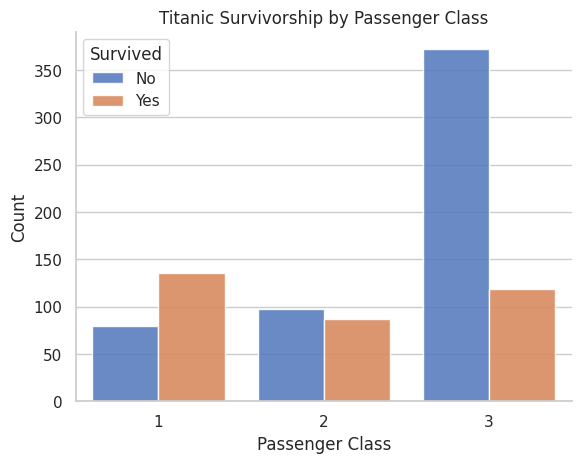

In [44]:
ax = sns.countplot(data=df, x="pclass", hue="survived", alpha=0.9)

ax.set_xlabel("Passenger Class")
ax.set_ylabel("Count")
ax.set_title("Titanic Survivorship by Passenger Class")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.savefig("../assets/surv_vs_pclass.png")
plt.show()

**Remarks**

- First-class passengers had the highest survival rate, with 63.0% of the
passengers surviving
- Survivorship among second-class passengers was roughly 50-50
- Third-class passengers had the lowest survival rate, with only 24.2% of the
passengers surviving

Visually, it seems that there's an association between passenger class and
survivorship. Let's test this claim statistically. We'll use the chi-square
test of independence.

We state the hypothesis:

- **$\text{H}_0$**: `survived` is independent of `pclass`
- **$\text{H}_\text{a}$**: `survived` is dependent on `pclass`

We'll set the significance level $\alpha = 0.05$.

p-value < 0.05: reject the null hypothesis


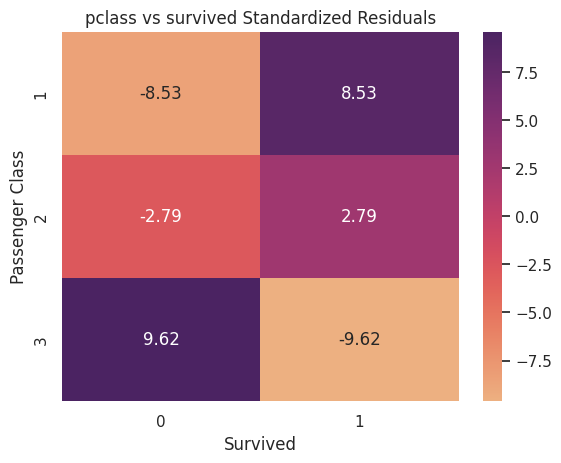

(np.float64(102.88898875696056),
 np.float64(4.549251711298793e-23),
 2,
 array([[133.09090909,  82.90909091],
        [113.37373737,  70.62626263],
        [302.53535354, 188.46464646]]),
 survived    0    1
 pclass            
 1          80  136
 2          97   87
 3         372  119)

In [45]:
chi_square_test(
    data=df,
    feature="pclass",
    xlabel="Survived",
    ylabel="Passenger Class",
    title="pclass vs survived Standardized Residuals",
    name="surv_vs_pclass_resids",
)

**Remarks**

- We observe significantly more survivors among first-class passengers than
expected
- We observe more survivors among second-class passengers than expected
- We observe significantly fewer survivors in third-class than expected

From the initial plot "Passenger Class versus Survived" and the chi-square
test of independence, we observe that `survived` is dependent on `pclass`:
first- and second-class passengers had higher survivorship rates than
expected. In comparison, third-class passengers had lower survivorship
rates.

### Sex versus Survived

In [46]:
describe_surv_vs_col(df, "sex", continuous=False)

Count      Percentage      
survived     0    1          0     1
sex                                 
female      81  233       25.8  74.2
male       468  109       81.1  18.9

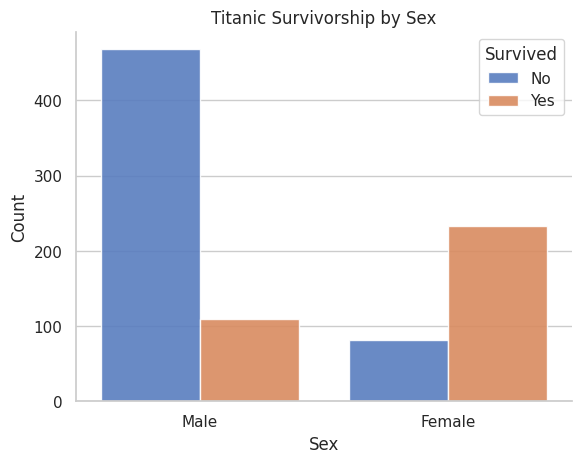

In [47]:
ax = sns.countplot(
    data=df, x="sex", hue="survived", alpha=0.9, order=["male", "female"]
)

ax.set_xticks([0, 1], ["Male", "Female"])

ax.set_xlabel("Sex")
ax.set_ylabel("Count")
ax.set_title("Titanic Survivorship by Sex")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.savefig("../assets/surv_vs_sex.png")
plt.show()

**Remarks**

- The majority of the males did not survive, while the majority of the females
did
- Most of the survivors are female, 74.2% to be exact

Visually, it seems that there's an association between sex and survivorship.
We'll use the chi-square test of independence to prove this statistically.

We state the hypothesis:

- **$\text{H}_0$**: `survived` is independent of `sex`
- **$\text{H}_\text{a}$**: `survived` is dependent on `sex`

We'll set the significance level $\alpha = 0.05$.

In [48]:
chi_square_test(data=df, feature="sex", heatmap=False)

p-value < 0.05: reject the null hypothesis


(np.float64(260.71702016732104),
 np.float64(1.1973570627755645e-58),
 1,
 array([[193.47474747, 120.52525253],
        [355.52525253, 221.47474747]]),
 survived    0    1
 sex               
 female     81  233
 male      468  109)

The observed p-value is significantly smaller than the determined $\alpha$.
Thus, we reject the null hypothesis and conclude that `survived` is dependent
on the `sex` variable.

What we can tell with confidence by looking at the plot and the result of the
chi-square test is that `sex` is a good predictor for the `survived` target
variable. In fact, recall that at the start of the project, we used an "all
female survived" type of model where the model predicted a passenger as
survived for females and did not survive for males. The model had a 78.7%
accuracy.

This evidence shows how important the `sex` feature is. What we historically
know from the Titanic incident, the famous line *"Women and children first!"*
seems to be true for the time being. We'll test for age next and verify what
we know and back it up with statistics.

### Age & Age Groups versus Survived

We'll investigate whether `age` had any effect on a passenger's survivorship
or not. We'll also check whether any particular `age_group` had higher chances
of survival.

In [49]:
describe_surv_vs_col(df.loc[df["age_was_missing"] == 0], "age", continuous=True)

,count,mean,median,std,min,max,q25,q75
survived,,,,,,,,
0,424,30.626179,28.0,14.172110,1.00,74.0,21.0,39.0
1,290,28.343690,28.0,14.950952,0.42,80.0,19.0,36.0


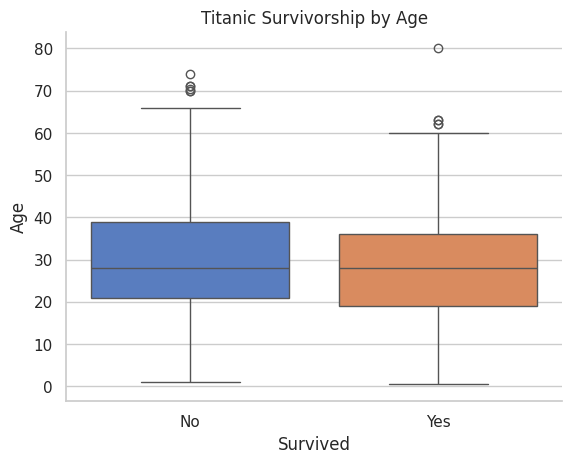

In [50]:
ax = sns.boxplot(
    data=df.loc[df["age_was_missing"] == 0],
    x="survived",
    y="age",
    hue="survived",
    legend=False,
    dodge=False,
)

ax.set_xticks([0, 1], ["No", "Yes"])

ax.set_xlabel("Survived")
ax.set_ylabel("Age")
ax.set_title("Titanic Survivorship by Age")

plt.savefig("../assets/surv_vs_age_box.png")
plt.show()

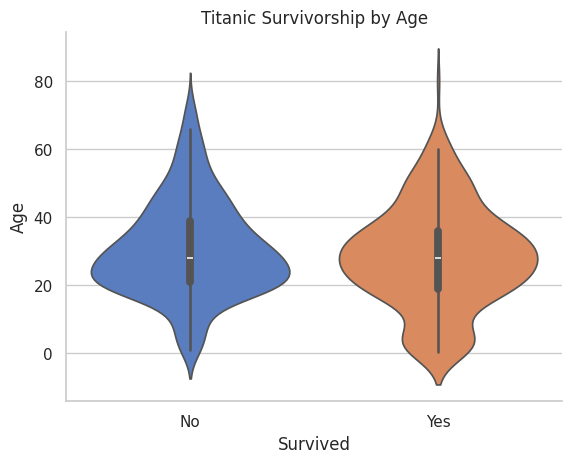

In [51]:
ax = sns.violinplot(
    data=df.loc[df["age_was_missing"] == 0],
    x="survived",
    y="age",
    hue="survived",
    legend=False,
    dodge=False,
)

ax.set_xticks([0, 1], ["No", "Yes"])

ax.set_xlabel("Survived")
ax.set_ylabel("Age")
ax.set_title("Titanic Survivorship by Age")

plt.savefig("../assets/surv_vs_age_vio.png")
plt.show()

**Remarks**

- From the descriptive statistics table, we see no huge differences:
  - The difference between the mean ages of the `survived` classes is 2-3
  years, while the median is exactly the same
  - Percentiles are roughly the same, with a 2-3 year difference
- Visually, box plots are very similar
- Visually, distributions seen in the violin plots look different
  - The survived class contains more observations on the left tail, while the
  did not survive class contains more observations on the right tail, meaning
  the survived class appears to contain a larger proportion of young
  passengers, while the non-survivors class seems to have relatively more
  observations in older age ranges
  - The survived class contains more observations around the median with a
  smoother distribution, while the other class has fewer observations with a
  sharper decline

Now, we should go back to our first claim from the `sex` section, Titanic's
famous *"Women and children first"* strategy. We should conduct a statistical
test just to be sure. For this, we'll compare the mean ages of the survivors
and victims.

We'll use the Mann-Whitney U test since the data is not normally distributed.
We meet the assumptions:

1. Observations are independent of each other
2. Groups are independent (survivors and victims) from each other
3. The variable (age) is continuous

Before proceeding with the Mann-Whitney U test, we should first confirm
whether the age distributions differ by survivor classes. Although we
suspected such differences visually, descriptive statistics did not provide
any useful information for this claim. Depending on the evidence, the
Mann-Whitney U test could be interpreted in two different ways. To test our
claims about the differences between age distributions, we'll use both
Levene's and KS tests with a significance level of $\alpha=0.05$.

In [52]:
stat, pval = stats.levene(
    df.loc[(df.survived == 0) & (df["age_was_missing"] == 0), "age"],
    df.loc[(df.survived == 1) & (df["age_was_missing"] == 0), "age"],
)
print(f"Levene Test p-value: {pval}")

stat, pval = stats.ks_2samp(
    df.loc[(df.survived == 0) & (df["age_was_missing"] == 0), "age"],
    df.loc[(df.survived == 1) & (df["age_was_missing"] == 0), "age"],
)
print(f"Kolmogorov-Smirnov Test p-value: {pval}")

Levene Test p-value: 0.2746162156000285
Kolmogorov-Smirnov Test p-value: 0.12277292350653973


In both tests, we fail to reject the null hypothesis. Therefore:

- There's no statistical evidence that the age distributions of the two
`survived` classes have unequal variances.
- There's no statistical evidence that the age distributions of the two
`survived` classes are drawn from different distributions.

Thus, there's no statistical evidence of unequal variances or of differences
in the age distributions at the 5% significance level. Now, what do we do? Do
we go by the visual cues of different shapes, or accept the lack of evidence
of such cases? We'll be conservative in deciding and interpreting the
Mann-Whitney U test as NOT a test of medians. We state the hypotheses as:

- **$\text{H}_0$**: There is no difference between the age distributions of
survivors and non-survivors:
$$
    P(X_\text{survivor} > X_\text{victim}) = 0.5
$$
- **$\text{H}_\text{a}$**: There is a difference between the age distributions
of survivors and non-survivors:
$$
    P(X_\text{survivor} > X_\text{victim}) \neq 0.5
$$

Essentially, we test whether a randomly selected survivor is equally likely to
be older than a randomly selected non-survivor as vice versa.

We'll set the significance level $\alpha = 0.05$.

In [53]:
survivors = df.loc[
    (df.survived == 1) & (df["age_was_missing"] == 0), "age"
].values
victims = df.loc[
    (df.survived == 0) & (df["age_was_missing"] == 0), "age"
].values

stat, pval = stats.mannwhitneyu(survivors, victims)

print(f"Stat: {stat}\np-value: {pval}")

P_VALS["age"] = pval

Stat: 57682.0
p-value: 0.16049252477737763


The computed p-value of 0.16 is greater than our determined $\alpha$ value.
Thus, we fail to reject the null hypothesis to conclude that there is no
difference between the age distributions of survivors and non-survivors.
Essentially, there is no statistical evidence to support the claim that a
randomly chosen survivor would necessarily be younger (or older) than a
randomly chosen victim, showing that there's no pattern.

However, these results do not necessarily explain our question to the full
extent. The Mann-Whitney U test explains that the overall age distributions
are not statistically different. However, it is possible that some specific
age groups, such as children, could have higher survival chances. Let's also
test for this fact. For that, we'll use the chi-square test of independence.
We'll use the same age groups we've defined earlier in the univariate analysis
section. Before we proceed with the tests, we'll generate plots and
descriptive statistics first.

In [54]:
describe_surv_vs_col(
    df.loc[df["age_was_missing"] == 0], "age_group", continuous=False
)

Count      Percentage      
survived        0    1          0     1
age_group                              
Child          29   39       42.6  57.4
Youth          23   22       51.1  48.9
Young Adult    92   42       68.7  31.3
Adult         202  141       58.9  41.1
Middle Aged    66   45       59.5  40.5
Aged           12    1       92.3   7.7

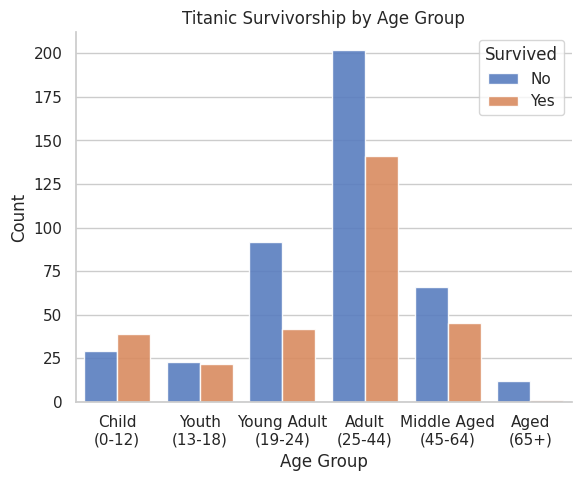

In [55]:
ax = sns.countplot(
    data=df.loc[df["age_was_missing"] == 0],
    x="age_group",
    hue="survived",
    alpha=0.9,
)

ax.set_xlabel("Age Group")
ax.set_ylabel("Count")
ax.set_title("Titanic Survivorship by Age Group")
plt.legend(title="Survived", labels=["No", "Yes"])

ax.set_xticks(
    range(6),
    [
        "Child\n(0-12)",
        "Youth\n(13-18)",
        "Young Adult\n(19-24)",
        "Adult\n(25-44)",
        "Middle Aged\n(45-64)",
        "Aged\n(65+)",
    ],
)

plt.savefig("../assets/surv_vs_age_group.png")
plt.show()

**Remarks**

- The only group with more survivors than victims is the child group, with a
53.8% survival rate
- The youth group had a 43.1% survival rate, the highest survival rate among
groups with a net negative survival rate
- The rest of the age groups had significantly fewer survivors than victims
- Out of the twelve 65+ year-old passengers, only one survived
- Adults were the majority group in both survivors and non-survivors

We should proceed with the chi-square test of independence, tested on
`age_group` versus `survived`. We state the hypothesis:

- **$\text{H}_0$**: `survived` is independent of `age_group`
- **$\text{H}_\text{a}$**: `survived` is dependent on `age_group`

We'll set the significance level $\alpha = 0.05$.

p-value < 0.05: reject the null hypothesis


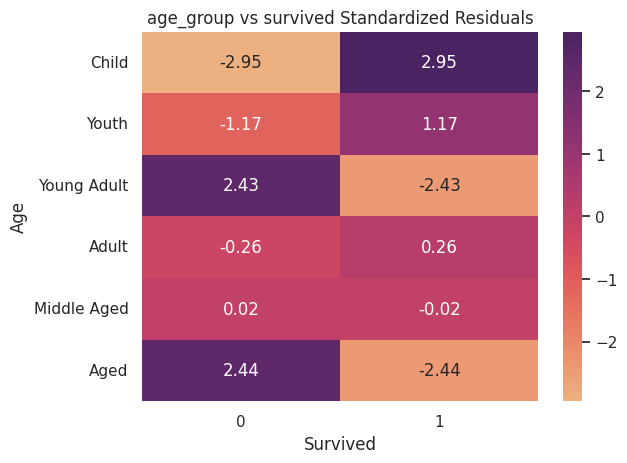

(np.float64(19.82852834918724),
 np.float64(0.0013457798078397407),
 5,
 array([[ 40.38095238,  27.61904762],
        [ 26.72268908,  18.27731092],
        [ 79.57422969,  54.42577031],
        [203.68627451, 139.31372549],
        [ 65.91596639,  45.08403361],
        [  7.71988796,   5.28011204]]),
 survived       0    1
 age_group            
 Child         29   39
 Youth         23   22
 Young Adult   92   42
 Adult        202  141
 Middle Aged   66   45
 Aged          12    1)

In [56]:
chi_square_test(
    data=df.loc[df["age_was_missing"] == 0],
    feature="age_group",
    heatmap=True,
    xlabel="Survived",
    ylabel="Age",
    title="age_group vs survived Standardized Residuals",
    name="surv_vs_age_group_resids",
)

**Remarks**

- Among children, survival rates are higher than expected
- The survival rate of aged passengers is less than expected
- The rest of the age groups had the expected survival rates
- The `survived` target is dependent on age groups

**Takeaways**

To sum up all the knowledge we've obtained by analyzing the `age` feature
against the target variable `survived`, specifically the groups "survived" and
"did not survive", we can state:

1. Descriptive statistics of the survived and not-survived groups are similar;
we don't observe huge differences
2. These groups have different-looking distributions. However, we found no
statistical evidence for different distributions for the two `survived`
classes
3. Despite the previous results, we've observed that certain age groups had
higher/lower chances of survival than expected

Now that we have both "Sex versus Survived" and "Age & Age Groups versus
Survived" covered, we can state that *"Women and children first"* was indeed
the reality of what happened in the tragedy.

### Siblings/Spouses versus Survived

In [57]:
describe_surv_vs_col(df, "sibsp", continuous=False)

Count        Percentage      
survived      0      1          0     1
sibsp                                  
0         398.0  210.0       65.5  34.5
1          97.0  112.0       46.4  53.6
2          15.0   13.0       53.6  46.4
3          12.0    4.0       75.0  25.0
4          15.0    3.0       83.3  16.7
5           5.0    NaN      100.0   NaN
8           7.0    NaN      100.0   NaN

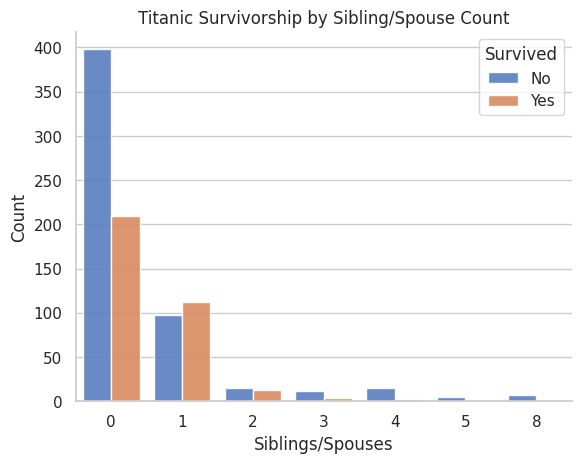

In [58]:
ax = sns.countplot(data=df, x="sibsp", hue="survived", alpha=0.9)

ax.set_xlabel("Siblings/Spouses")
ax.set_ylabel("Count")
ax.set_title("Titanic Survivorship by Sibling/Spouse Count")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.savefig("../assets/surv_vs_sibsp.png")
plt.show()

**Remarks**

- Groups `sibsp == 1` and `sibsp == 2` had balanced survivors and
non-survivors
- For `sibsp` equals 0, 3, and 4, there are more non-survivors
- Groups 5 and 8 had no survivors at all

We suspect that `survived` might be dependent based on what we've observed
from the plot. Let's conduct a chi-square test of independence to be sure.
We'll drop the 5th and 8th columns since they have no survivors, and that
would violate data assumptions for the test otherwise.

We state the hypothesis:

- **$\text{H}_0$**: `survived` is independent of `sibsp`
- **$\text{H}_\text{a}$**: `survived` is dependent on `sibsp`

We'll set the significance level $\alpha = 0.05$.

In [59]:
chi_square_test(
    data=df,
    feature="sibsp",
    xlabel="Survived",
    ylabel="Siblings/Spouse",
    title="sibsp vs survived Standardized Residuals",
    name="surv_vs_sibsp_resids",
)

Chi-square assumptions violated: 4/14 _expected counts < 5 (>20%).
Contingency Table:
survived    0    1
sibsp             
0         398  210
1          97  112
2          15   13
3          12    4
4          15    3
5           5    0
8           7    0


p-value < 0.05: reject the null hypothesis


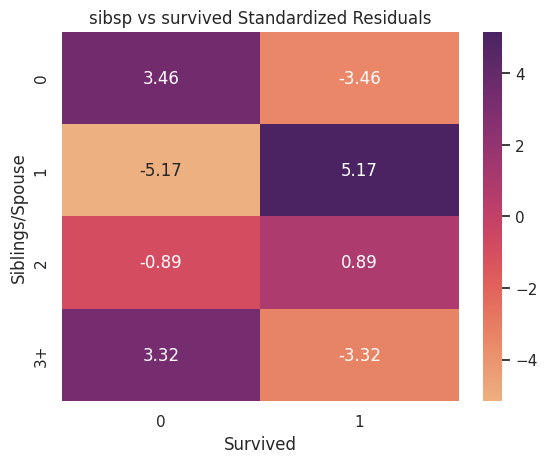

(np.float64(35.433439011914366),
 np.float64(9.866170943864991e-08),
 3,
 array([[374.62626263, 233.37373737],
        [128.77777778,  80.22222222],
        [ 17.25252525,  10.74747475],
        [ 28.34343434,  17.65656566]]),
 survived       0    1
 sibsp_group          
 0            398  210
 1             97  112
 2             15   13
 3+            39    7)

In [60]:
df["sibsp_group"] = df["sibsp"].apply(lambda x: "3+" if x >= 3 else str(x))


chi_square_test(
    data=df,
    feature="sibsp_group",
    xlabel="Survived",
    ylabel="Siblings/Spouse",
    title="sibsp vs survived Standardized Residuals",
    name="surv_vs_sibsp_resids",
)

**Remarks**

- The passengers without siblings and spouses on board had significantly fewer
survivors than expected
- The passengers with a sibling or a spouse had significantly higher survival
rates than expected
- The passengers with `sibsp == 2` had as expected survival rates
- The passengers with 3 or more siblings plus spouse had lower than expected
survival rates

The `sibsp == 0` case could be explained by the fact that the Titanic had
numerous workers traveling to the United States. This idea is in line with our
previous results from the `pclass` section, where we observed a higher number
of non-survivors among third-class passengers, many of whom were the said
workers. On the other hand, bigger families did not survive at expected rates.
Instead, they had fewer survivors than expected.

We will dive deeper into this suspicion in the multivariate analysis section.

### Parents/Children versus Survived

In [61]:
describe_surv_vs_col(df, "parch", continuous=False)

Count        Percentage      
survived      0      1          0     1
parch                                  
0         445.0  233.0       65.6  34.4
1          53.0   65.0       44.9  55.1
2          40.0   40.0       50.0  50.0
3           2.0    3.0       40.0  60.0
4           4.0    NaN      100.0   NaN
5           4.0    1.0       80.0  20.0
6           1.0    NaN      100.0   NaN

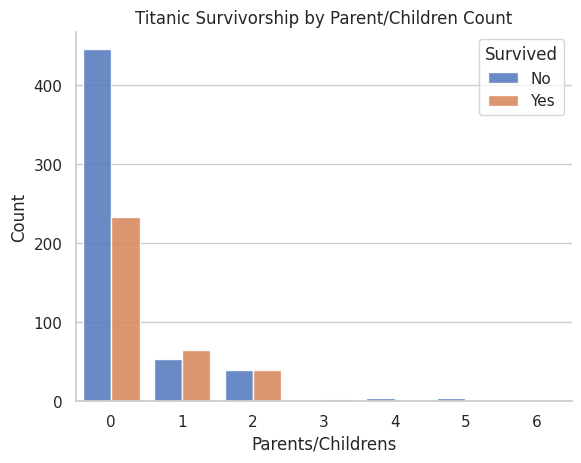

In [62]:
ax = sns.countplot(data=df, x="parch", hue="survived", alpha=0.9)

ax.set_xlabel("Parents/Childrens")
ax.set_ylabel("Count")
ax.set_title("Titanic Survivorship by Parent/Children Count")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.savefig("../assets/surv_vs_parch.png")
plt.show()

**Remarks**

- Groups 0 and 5 had significantly more non-survivors than survivors
- `parch == 1` group had more survivors
- `parch == 2` group had exactly as many survivors as victims
- Groups 4 and 6 had no survivors

Same with the last case, we suspect that the target variable `survived` is
dependent on the feature `parch`; thus, we'll conduct a chi-square test of
independence. We'll drop columns 4 and 6 to satisfy the data assumptions.

We state the hypothesis:

- **$\text{H}_0$**: `survived` is independent of `parch`
- **$\text{H}_\text{a}$**: `survived` is dependent on `parch`

We'll set the significance level $\alpha = 0.05$.

In [63]:
chi_square_test(
    data=df,
    feature="parch",
    xlabel="Survived",
    ylabel="Parents/Children",
    title="parch vs survived Standardized Residuals",
    name="surv_vs_parch_resids",
)

Chi-square assumptions violated: _expected counts < 1 detected.
Contingency Table:
survived    0    1
parch             
0         445  233
1          53   65
2          40   40
3           2    3
4           4    0
5           4    1
6           1    0


p-value < 0.05: reject the null hypothesis


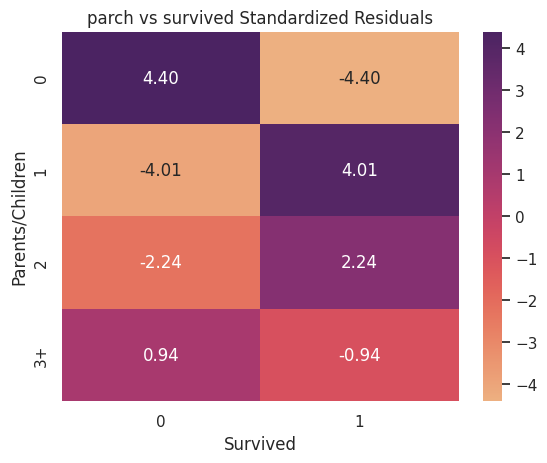

(np.float64(23.979451014507088),
 np.float64(2.5227955142443437e-05),
 3,
 array([[417.75757576, 260.24242424],
        [ 72.70707071,  45.29292929],
        [ 49.29292929,  30.70707071],
        [  9.24242424,   5.75757576]]),
 survived       0    1
 parch_group          
 0            445  233
 1             53   65
 2             40   40
 3+            11    4)

In [64]:
df["parch_group"] = df["parch"].apply(lambda x: "3+" if x >= 3 else str(x))
chi_square_test(
    data=df,
    feature="parch_group",
    xlabel="Survived",
    ylabel="Parents/Children",
    title="parch vs survived Standardized Residuals",
    name="surv_vs_parch_resids",
)

**Remarks**

- The passengers with no parents or children had significantly lower survival
rates than expected
- The passengers with a parent or a child had significantly higher survival
rates than expected
- The passengers with 2 parents and/or children had slightly higher survival
rates than expected
- The passengers with 3 or more parents and  children had expected survival
rates

### Fare & Fare Per Person versus Survived

We'll investigate whether `fare` had any effect on a passenger's survivorship
or not. We'll also check the extracted feature `fare_per_person` against
`survived`.

In [65]:
describe_surv_vs_col(df, "fare", continuous=True)

,count,mean,median,std,min,max,q25,q75
survived,,,,,,,,
0,549,22.117887,10.5,31.388207,0.0,263.0000,7.8542,26.0
1,342,48.395408,26.0,66.596998,0.0,512.3292,12.4750,57.0


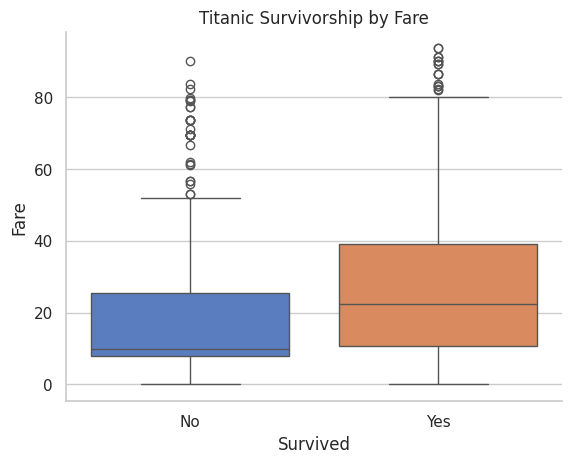

In [66]:
ax = sns.boxplot(
    data=df.loc[df.fare <= 100],
    x="survived",
    y="fare",
    hue="survived",
    legend=False,
    dodge=False,
)

ax.set_xticks([0, 1], ["No", "Yes"])

ax.set_xlabel("Survived")
ax.set_ylabel("Fare")
ax.set_title("Titanic Survivorship by Fare")

plt.savefig("../assets/surv_vs_fare_box.png")
plt.show()

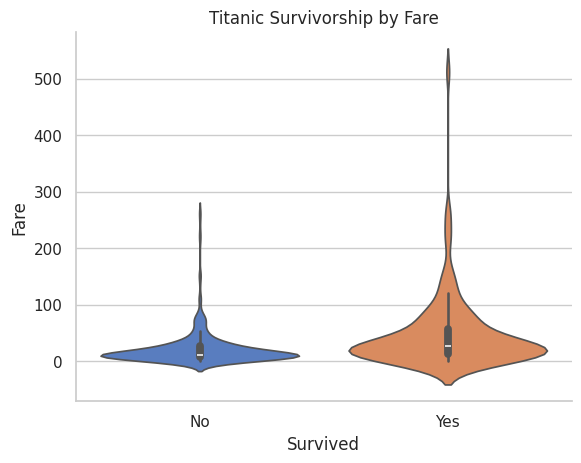

In [67]:
ax = sns.violinplot(
    data=df, x="survived", y="fare", hue="survived", legend=False, dodge=False
)

ax.set_xticks([0, 1], ["No", "Yes"])

ax.set_xlabel("Survived")
ax.set_ylabel("Fare")
ax.set_title("Titanic Survivorship by Fare")

plt.savefig("../assets/surv_vs_fare_vio.png")
plt.show()

**Remarks**

- Survived passengers paid higher fares across the statistics: mean, median,
etc.
- Survivors had more extreme fare outliers relative to the IQR compared to
non-survivors
- The fare difference between the `survived` groups is so extreme that the
25th percentile of the survived passengers' fare, GBP 12.5, is more than the
median non-survived passenger fare
- Both the mean and the median of the survived passenger fares are more than
double those of the non-survived passenger fares

We'll still conduct a statistical test regardless of how obvious the
relationship may look. We're testing two independent groups with non-normal
distributions of continuous, independent variables against a dependent
variable, `fare` versus `survived`. Therefore, we'll use the Mann-Whitney U
test since it is non-parametric and we also satisfy the other conditions.
However, before we state our hypothesis, we should determine whether the
distributions of survived and non-survived passenger fares are similar or not.

In [68]:
stat, pval = stats.levene(
    df[df.survived == 0]["fare"], df[df.survived == 1]["fare"]
)

print(f"Levene Test p-value: {pval}")
stat, pval = stats.ks_2samp(
    df[df.survived == 0]["fare"], df[df.survived == 1]["fare"]
)

print(f"Kolmogorov-Smirnov Test p-value: {pval}")

Levene Test p-value: 3.3373527106271484e-11
Kolmogorov-Smirnov Test p-value: 1.606244624491715e-17


Because the Levene and K-S tests show the groups have unequal variances and
distribution shapes, we cannot use the Mann-Whitney U test to evaluate a
difference in medians. Then, we can state our hypothesis for the Mann-Whitney
test as follows:

- **$\text{H}_0$**: There is no difference between the fare distributions of
survivors and non-survivors:
$$
    P(X_\text{survivor} > X_\text{victim}) = 0.5
$$
- **$\text{H}_\text{a}$**: There is a difference between the fare
distributions of survivors and non-survivors:
$$
    P(X_\text{survivor} > X_\text{victim}) \neq 0.5
$$

We'll set the significance level $\alpha = 0.05$.

In [69]:
survivors = df.loc[df.survived == 1, "fare"].values
victims = df.loc[df.survived == 0, "fare"].values

stat, pval = stats.mannwhitneyu(survivors, victims)

print(f"Stat: {stat}\np-value: {pval}")

P_VALS["fare"] = pval

Stat: 129951.5
p-value: 4.553477179250237e-22


Since the resulting p-value is less than our significance level $\alpha$, we
reject the null hypothesis to conclude that fare distributions of survivors
and non-survivors differ. Therefore, `fare` is associated with a passenger's
survival status.

Next up, we should analyze the `fare_per_person` feature as well. Recall that
we extracted this feature using `fare`, `sibsp`, `parch`, and `ticket`
columns. We took the number of occurences of a passenger's ticket number and
compared it to `sibsp + parch + 1`, which is the family size. We took the
bigger of the two variables and divided `fare` by that amount to get an
approximation.

In [70]:
describe_surv_vs_col(df, "fare_per_person", continuous=True)

,count,mean,median,std,min,max,q25,q75
survived,,,,,,,,
0,549,12.054411,7.8958,14.321551,0.0,221.7792,7.225,12.00000
1,342,20.936435,12.8250,22.022689,0.0,170.7764,7.750,28.33595


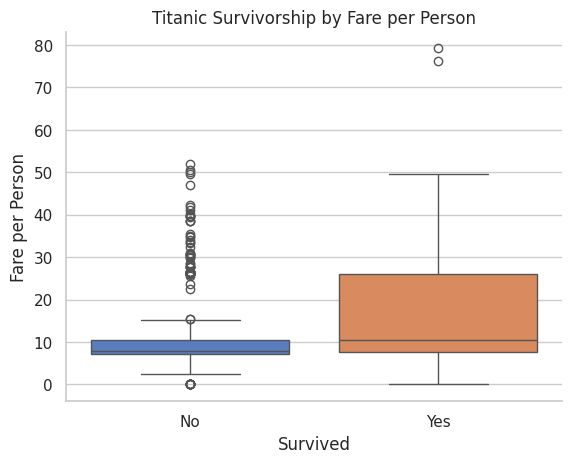

In [71]:
ax = sns.boxplot(
    data=df.loc[df.fare <= 100],
    x="survived",
    y="fare_per_person",
    hue="survived",
    legend=False,
    dodge=False,
)

ax.set_xticks([0, 1], ["No", "Yes"])

ax.set_xlabel("Survived")
ax.set_ylabel("Fare per Person")
ax.set_title("Titanic Survivorship by Fare per Person")

plt.savefig("../assets/surv_vs_fare_per_person_box.png")
plt.show()

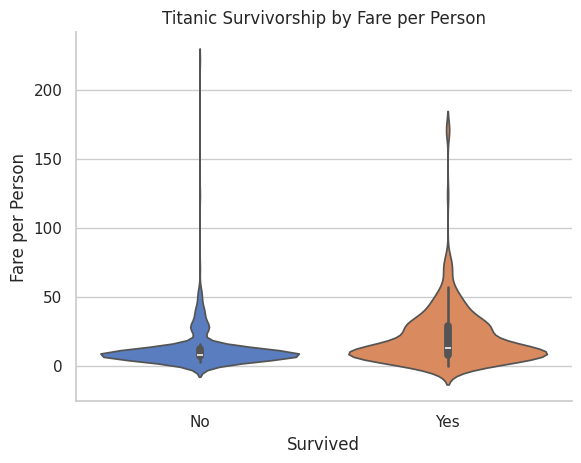

In [72]:
ax = sns.violinplot(
    data=df,
    x="survived",
    y="fare_per_person",
    hue="survived",
    legend=False,
    dodge=False,
)

ax.set_xticks([0, 1], ["No", "Yes"])

ax.set_xlabel("Survived")
ax.set_ylabel("Fare per Person")
ax.set_title("Titanic Survivorship by Fare per Person")

plt.savefig("../assets/surv_vs_fare_per_person_vio.png")
plt.show()

**Remarks**

Similar to the plain `fare` case

- Mean and median fares are much higher in survived class
- Spread is higher in survived class
- Distributions between two classes appear to be different

We should test whether these two distributions are similar or not. We'll use
Levene and KS tests once again, with the usual significance level set at
$\alpha = 0.05$.

In [73]:
stat, pval = stats.levene(
    df[df.survived == 0]["fare_per_person"],
    df[df.survived == 1]["fare_per_person"],
)

print(f"Levene Test p-value: {pval}")
stat, pval = stats.ks_2samp(
    df[df.survived == 0]["fare_per_person"],
    df[df.survived == 1]["fare_per_person"],
)

print(f"Kolmogorov-Smirnov Test p-value: {pval}")

Levene Test p-value: 2.1713561273564076e-11
Kolmogorov-Smirnov Test p-value: 1.8159783910238188e-16


In [74]:
survivors = df.loc[df.survived == 1, "fare_per_person"].values
victims = df.loc[df.survived == 0, "fare_per_person"].values

stat, pval = stats.mannwhitneyu(survivors, victims)

print(f"Stat: {stat}\np-value: {pval}")

P_VALS["fare_per_person"] = pval

Stat: 123674.5
p-value: 1.4802511667200603e-15


In both the Levene and the KS tests, we reject the null hypothesis to conclude
that `fare_per_person` distributions across the two `survived` classes have
unequal variance and shapes. Therefore, the Mann-Whitney U test answers the
question of whether the fare distribution differs between survivors and
non-survivors, similar to the plain `fare` case. Again, we reject the null
hypothesis to conclude that the `fare_per_person` distributions of survivors
and non-survivors differ. Therefore, `fare_per_person` is associated with a
passenger's survival status.

Note here that this result is expected. At this point, it is feasible to
suspect whether fare per person, or fare itself in general, is a proxy for
other variables, especially `pclass`. Fare is supposed to be directly related
to passenger class from an intuition stand of view. We'll rigorously test for
these suspicions in the multivariate analysis section.

### Embarked versus Survived

In [75]:
describe_surv_vs_col(df, "embarked", continuous=False)

Count      Percentage      
survived     0    1          0     1
embarked                            
C           75   95       44.1  55.9
Q           47   30       61.0  39.0
S          427  217       66.3  33.7

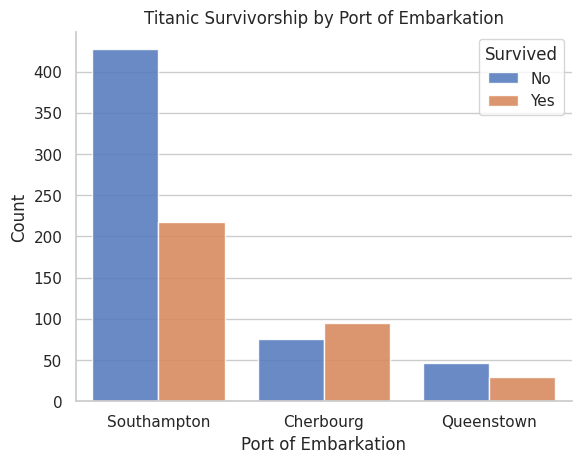

In [76]:
ax = sns.countplot(
    data=df, x="embarked", hue="survived", alpha=0.9, order=["S", "C", "Q"]
)

ax.set_xticks([0, 1, 2], ["Southampton", "Cherbourg", "Queenstown"])

ax.set_xlabel("Port of Embarkation")
ax.set_ylabel("Count")
ax.set_title("Titanic Survivorship by Port of Embarkation")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.savefig("../assets/surv_vs_embarked.png")
plt.show()

**Remarks**

- There are more victims than survivors among passengers who embarked from
Queenstown and Southampton
- There are more survivors among passengers who embarked from Cherbourg

Let's conduct a statistical test to see if there's a relationship between
survivorship and port of embarkation. For this, we'll use the chi-square test
of independence.

We state the hypothesis:

- **$\text{H}_0$**: `survived` is independent of `embarked`
- **$\text{H}_\text{a}$**: `survived` is dependent on `embarked`

We'll set the significance level $\alpha = 0.05$.

p-value < 0.05: reject the null hypothesis


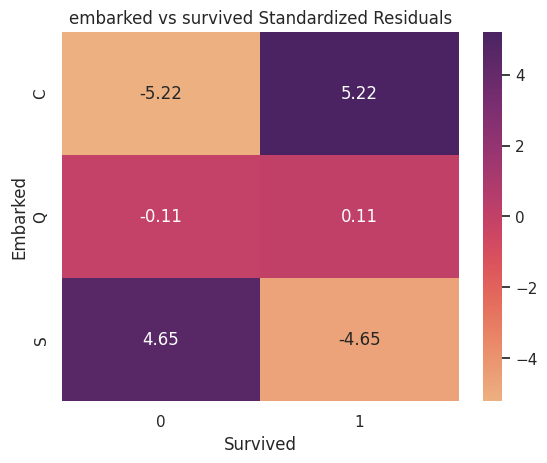

(np.float64(28.005088727541892),
 np.float64(8.294156968447598e-07),
 2,
 array([[104.74747475,  65.25252525],
        [ 47.44444444,  29.55555556],
        [396.80808081, 247.19191919]]),
 survived    0    1
 embarked          
 C          75   95
 Q          47   30
 S         427  217)

In [77]:
chi_square_test(
    data=df,
    feature="embarked",
    xlabel="Survived",
    ylabel="Embarked",
    title="embarked vs survived Standardized Residuals",
    name="surv_vs_embarked_resids",
)

**Remarks**

- Passengers who embarked from Cherbourg survived at a rate significantly
higher than expected
- Passengers who embarked from Southampton survived at a rate significantly
less than expected
- Survival rates among passengers who embarked from Queenstown are as expected

Although we've found a statistically significant relationship between
`survived` and `embarked`, logically it wouldn't make sense for the port of
embarkation to directly influence a passenger's survival. Therefore, it is
possible that `embarked` is a proxy for `survived`, where this feature embeds
other features, such as passenger class. We'll test for this in the next
section, which is multivariate analysis.

### Deck versus Survived

In [78]:
describe_surv_vs_col(df, "deck", continuous=False)

Count       Percentage      
survived      0     1          0     1
deck                                  
A          10.0   7.0       58.8  41.2
B          19.0  37.0       33.9  66.1
C          32.0  47.0       40.5  59.5
D          62.0  58.0       51.7  48.3
E         166.0  84.0       66.4  33.6
F         188.0  80.0       70.1  29.9
G          71.0  29.0       71.0  29.0
T           1.0   NaN      100.0   NaN

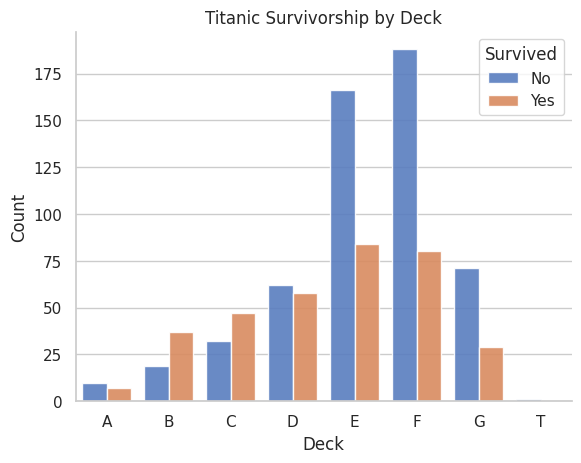

In [79]:
ax = sns.countplot(
    data=df,
    x="deck",
    hue="survived",
    alpha=0.9,
    order=["A", "B", "C", "D", "E", "F", "G", "T"],
)

ax.set_xlabel("Deck")
ax.set_ylabel("Count")
ax.set_title("Titanic Survivorship by Deck")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.savefig("../assets/surv_vs_deck.png")
plt.show()

**Remarks**

- There are more survivors than victims among passengers who traveled on decks
B and C, with deck B having the highest survival rate
- Decks E, F, and G had significantly fewer survivors than victims
- The only passenger to travel in the T deck did not survive
- Decks A and D have a roughly 50-50 survival rate

There seems to be a relationship between `deck` and `survived`. Let's conduct
a chi-square test of independence just to be sure. Since deck T includes an
expected value of 0, it violates the assumptions of the chi-square test. Thus,
we'll drop the T deck before performing the test.

We state the hypothesis:

- **$\text{H}_0$**: `survived` is independent of `deck`
- **$\text{H}_\text{a}$**: `survived` is dependent on `deck`

We'll set the significance level $\alpha = 0.05$.

p-value < 0.05: reject the null hypothesis


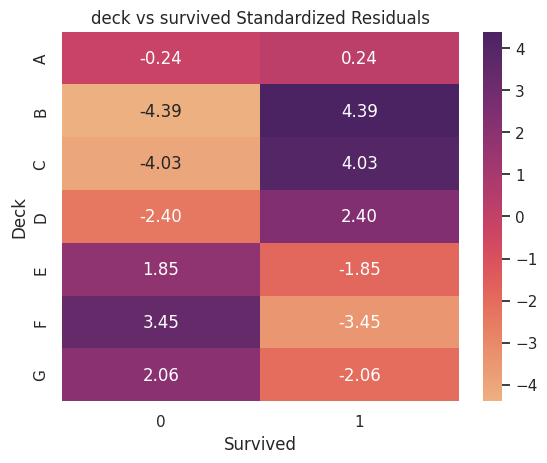

(np.float64(52.48593352837929),
 np.float64(1.4889767566027275e-09),
 6,
 array([[ 10.46741573,   6.53258427],
        [ 34.48089888,  21.51910112],
        [ 48.64269663,  30.35730337],
        [ 73.88764045,  46.11235955],
        [153.93258427,  96.06741573],
        [165.01573034, 102.98426966],
        [ 61.57303371,  38.42696629]]),
 survived    0   1
 deck             
 A          10   7
 B          19  37
 C          32  47
 D          62  58
 E         166  84
 F         188  80
 G          71  29)

In [80]:
df_deck = df.loc[df.deck != "T"]
chi_square_test(
    data=df_deck,
    feature="deck",
    xlabel="Survived",
    ylabel="Deck",
    title="deck vs survived Standardized Residuals",
    name="surv_vs_deck_resids",
)

**Remarks**

- Deck A and E had expected survival rates
- For decks B and C, survival rates were significantly higher than expected
- Deck D had higher-than-expected survival rates
- Deck G had lower-than-expected survival rates
- Deck F had significantly fewer survivors than expected

There's statistical evidence that `deck` is related to `survived`. The reasons
could vary. For starters, some decks could have easier access to the boat deck
where lifeboats were situated, which could explain why a passenger
accommodated on the deck could explain his/her survival chance to some extent.
On the other hand, the deck is directly related to passenger class and fare,
which are also related to the survival rates. Hence, we can't say for certain
whether the deck feature directly contributes to survival chance or not, which
we'll test in multivariate analysis.

Also note here that this correlation may be a result of the imputed values.
We've imputed the deck using `pclass` and `fare_per_person`, and
`fare_per_person` is engineered from other features, all of which we have
found to be correlated or associated with the target variable to some degree.
Therefore, the relationships we've observed in this section of the analysis
may be results of carried signal from other, maybe even more important
variables.

### Title versus Survived

We'll investigate whether `title` had any effect on a passenger's survivorship
or not. We'll combine every title with fewer than 7 occurrences into a single
group so that it's easier to plot and conduct a statistical test.

In [81]:
title_counts = df["title"].value_counts()


df["title_group"] = df["title"].apply(
    lambda x: (
        "Other" if x not in title_counts.index or title_counts[x] < 7 else x
    )
)

describe_surv_vs_col(df, "title_group", continuous=False)

Count      Percentage      
survived        0    1          0     1
title_group                            
Dr.             4    3       57.1  42.9
Master.        17   23       42.5  57.5
Miss.          55  127       30.2  69.8
Mr.           436   81       84.3  15.7
Mrs.           26   99       20.8  79.2
Other          11    9       55.0  45.0

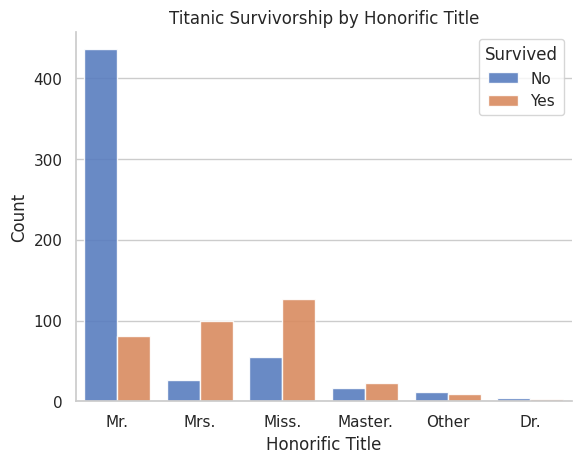

In [82]:
ax = sns.countplot(data=df, x="title_group", hue="survived", alpha=0.9)

ax.set_xlabel("Honorific Title")
ax.set_ylabel("Count")
ax.set_title("Titanic Survivorship by Honorific Title")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.savefig("../assets/surv_vs_title.png")
plt.show()

**Remarks**

- Male-only titles except Master. more victims than survivors
- Female-only titles had more survivors than victims

The results are in line with the section where we analyzed `survived` versus
`sex`. Recall that the `title` column was extracted to verify the `sex`
column. Thus, the results are as expected. Let's conduct a chi-square test of
independence.

We state the hypothesis:

- **$\text{H}_0$**: `survived` is independent of `title`
- **$\text{H}_\text{a}$**: `survived` is dependent on `title`

We'll set the significance level $\alpha = 0.05$.

p-value < 0.05: reject the null hypothesis


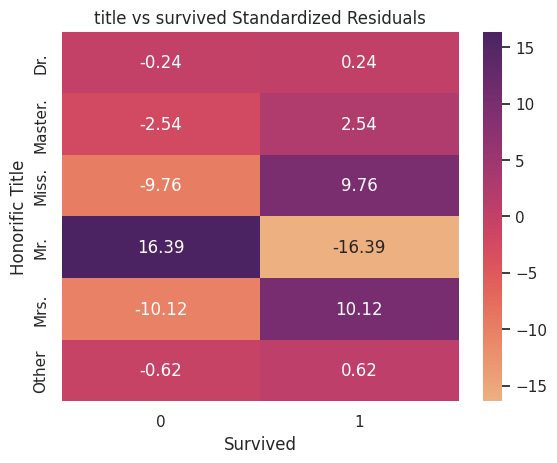

(np.float64(283.32157613833493),
 np.float64(3.84884260612239e-59),
 5,
 array([[  4.31313131,   2.68686869],
        [ 24.64646465,  15.35353535],
        [112.14141414,  69.85858586],
        [318.55555556, 198.44444444],
        [ 77.02020202,  47.97979798],
        [ 12.32323232,   7.67676768]]),
 survived       0    1
 title_group          
 Dr.            4    3
 Master.       17   23
 Miss.         55  127
 Mr.          436   81
 Mrs.          26   99
 Other         11    9)

In [83]:
chi_square_test(
    data=df,
    feature="title_group",
    xlabel="Survived",
    ylabel="Honorific Title",
    title="title vs survived Standardized Residuals",
    name="surv_vs_title_resids",
)

**Remarks**

- Mr. title had extremely lower survival rates than expected
- Mrs. and Miss. titles had extremely higher survival rates than expected
- Master. title had higher survival rates than expected
- The rest of the groups are as expected

These are the most extreme residuals we've encountered so far. A good reason
for this could be the fact that titles can reflect both age and sex. We'll
investigate this assumption in greater detail at later stages.

In addition, as with the `embarked` and `deck` features, we can't be sure
whether a passenger's title directly contributes to their survival chances. An
honorific title is directly related to sex, which explains survival chances to
a great extent. Therefore, we'll test the title feature in a multivariate
analysis and determine whether it's a proxy for or directly related to
`survived`.

### Family Size versus Survived

In [84]:
describe_surv_vs_col(df, "famsize", continuous=False)

Count        Percentage      
survived      0      1          0     1
famsize                                
1         374.0  163.0       69.6  30.4
2          72.0   89.0       44.7  55.3
3          43.0   59.0       42.2  57.8
4           8.0   21.0       27.6  72.4
5          12.0    3.0       80.0  20.0
6          19.0    3.0       86.4  13.6
7           8.0    4.0       66.7  33.3
8           6.0    NaN      100.0   NaN
11          7.0    NaN      100.0   NaN

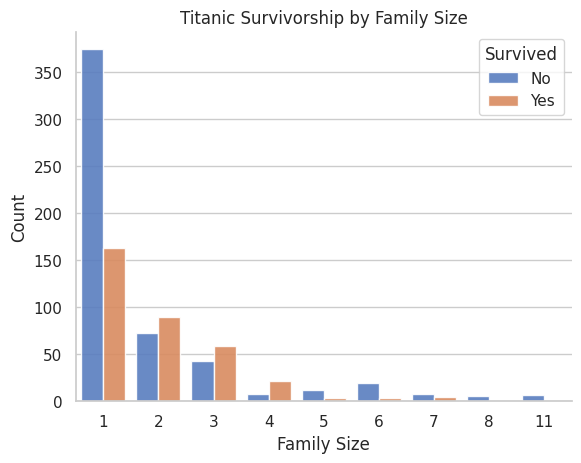

In [85]:
ax = sns.countplot(data=df, x="famsize", hue="survived", alpha=0.9, legend=True)

ax.set_xlabel("Family Size")
ax.set_ylabel("Count")
ax.set_title("Titanic Survivorship by Family Size")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.savefig("../assets/surv_vs_famsize.png")
plt.show()

**Remarks**

- Passengers who traveled solo had only a 30% survival rate
- Passengers with 2, 3, and 4 family members traveling together had survival
rates higher than 50%
- Families with more than 4 members had significantly lower survival rates

Let's conduct a simple chi-square test and analyze the standardized residuals
to prove what we've interpreted from the data.

We state the hypothesis:

- **$\text{H}_0$**: `survived` is independent of `famsize`
- **$\text{H}_\text{a}$**: `survived` is dependent on `famsize`

We'll set the significance level $\alpha = 0.05$.

In [86]:
chi_square_test(
    data=df,
    feature="famsize",
    xlabel="Survived",
    ylabel="Family Size",
    title="famsize vs survived Standardized Residuals",
    name="surv_vs_famsize_resids",
)

Chi-square assumptions violated: 5/18 _expected counts < 5 (>20%).
Contingency Table:
survived    0    1
famsize           
1         374  163
2          72   89
3          43   59
4           8   21
5          12    3
6          19    3
7           8    4
8           6    0
11          7    0


p-value < 0.05: reject the null hypothesis


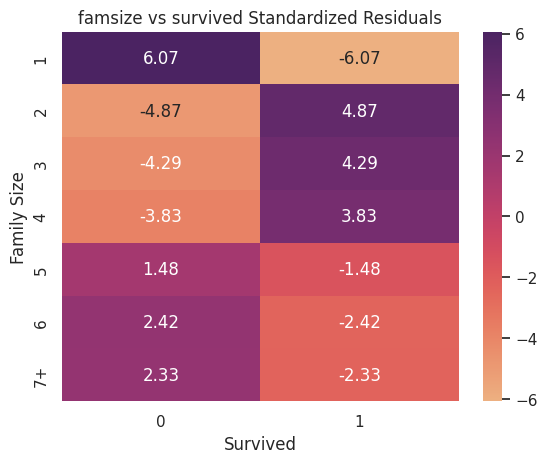

(np.float64(77.74075174671776),
 np.float64(1.0455722031582118e-14),
 6,
 array([[330.87878788, 206.12121212],
        [ 99.2020202 ,  61.7979798 ],
        [ 62.84848485,  39.15151515],
        [ 17.86868687,  11.13131313],
        [  9.24242424,   5.75757576],
        [ 13.55555556,   8.44444444],
        [ 15.4040404 ,   9.5959596 ]]),
 survived         0    1
 famsize_group          
 1              374  163
 2               72   89
 3               43   59
 4                8   21
 5               12    3
 6               19    3
 7+              21    4)

In [87]:
df["famsize_group"] = df["famsize"].apply(lambda x: "7+" if x >= 7 else str(x))

chi_square_test(
    data=df,
    feature="famsize_group",
    xlabel="Survived",
    ylabel="Family Size",
    title="famsize vs survived Standardized Residuals",
    name="surv_vs_famsize_resids",
)

**Remarks**

- Solo passengers survived at a significantly lower rate than expected
- Families of 2, 3, and 4 survived at a significantly higher rate than
expected
- Bigger families of 6 or more survived at a lower rate than expected
- Survival rate of families of 5 is as expected

Family size is statistically proven to be related to a passenger's
survivorship. However, we're still not sure of the exact relationship between
these two variables. For example, one answer to why passengers traveling solo
survived at a significantly lower rate can be the fact that a lot of
third-class passengers were traveling to NYC as part of the workforce. These
people might not have gotten the opportunity to take the lifeboats over other,
more prioritized passengers, such as women and children.

One other aspect we can point to by looking at the residuals is about families
of 2, 3, and 4. Certainly, there was a considerable number of women who
traveled with their children. We don't know yet whether there's a hidden
meaning behind the family size like those we've stated or if it's just a
numbers game. However, our intuition is to the contrary, as bigger families
did not survive at expected rates.

Let us first investigate the first claim. We claimed that the reason
passengers traveling solo survived at a lower rate is due to them being mostly
male workers traveling in the third-class.

### Test Validation

Now that we've run all the statistical tests to find evidence supporting our
claims, we need to validate the results. The reason is that we've conducted 12
tests, all at a significance level of $\alpha=0.05$. Since all these tests are
conducted against the single, unchanging target, `survived`, we run into the
issue of accumulating odds of errors.

To control the family-wise error rate, we'll apply the Holm-Bonferroni method.

In [88]:
tests, pvalues = zip(*P_VALS.items(), strict=True)

sort_index = np.argsort(pvalues)

tests = [tests[x] for x in sort_index]
pvalues = [pvalues[x] for x in sort_index]

reject, pvals_corrected, _, _ = multipletests(
    pvalues, alpha=0.05, method="holm", is_sorted=True
)

results = pd.DataFrame(
    {
        "Test": tests,
        "p-value": pvalues,
        "Adjusted p-value": pvals_corrected,
        "Reject": reject,
    }
)

print(results)

               Test       p-value  Adjusted p-value  Reject
0       title_group  3.848843e-59      4.618611e-58    True
1               sex  1.197357e-58      1.317093e-57    True
2            pclass  4.549252e-23      4.549252e-22    True
3              fare  4.553477e-22      4.098129e-21    True
4   fare_per_person  1.480251e-15      1.184201e-14    True
5     famsize_group  1.045572e-14      7.319005e-14    True
6              deck  1.488977e-09      8.933861e-09    True
7       sibsp_group  9.866171e-08      4.933085e-07    True
8          embarked  8.294157e-07      3.317663e-06    True
9       parch_group  2.522796e-05      7.568387e-05    True
10        age_group  1.345780e-03      2.691560e-03    True
11              age  1.604925e-01      1.604925e-01   False


After p-values are adjusted for accumulating errors by the Holm-Bonferroni
method, our results remain the same. Although not a definitive answer to our
questions, as is the case with any statistical method, we can assert that we
have found no statistical evidence contrary to either the tests conducted or
the interpretations concluded in this section.

### Summary

- We have found that the `survived` target variable is dependent on every
single feature we've tested in this section except for `age`
- We'll check whether `embarked`, `deck`, and `title` are proxies or not
- Although the relationship isn't immediately visible in some cases, for
example, the statistical tests we've conducted did not provide information on
association in the case of the age feature, we've still found that there exist
naturally occurring groups whose survival chances were higher than expected.
- We've validated our test results and found no evidence contrary to their
claims and interpretations

These remarks conclude the bivariate analysis section of the EDA phase. We'll
proceed with the multivariate analysis in the next notebook.